# Setup

In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery
library(data.table )

# Load required libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

# Install and load metafor if needed
if (!requireNamespace("metafor", quietly = TRUE)) install.packages("metafor")
library(metafor)
library(dplyr)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)



[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is

In [2]:
name_of_file_in_bucket <- 'imputed_individual_level_SDOH.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
sdoh_data  <- read_csv(name_of_file_in_bucket)
sdoh_data <- sdoh_data |> select(-c("Education"))

character(0)

Rows: 54313 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): SexGender
dbl (30): person_id, race_unknown, record_depth, visit_frequency, age, Educa...
lgl  (6): Black, Mid, Multiple, White, His, AANHPI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load and merge data

In [3]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Case_Control_df.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
Case_Control_df  <- read_csv(name_of_file_in_bucket)

character(0)

Rows: 266354 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): person_id, Asthma, Afib, BreastC, CKD, CHD, HyperC, ProstateC, t2d...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
merged_data<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

In [5]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'CFA_domain_SDOH_scores'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
CFA_domain_SDOH_scores  <- read_csv(name_of_file_in_bucket)
str(CFA_domain_SDOH_scores)

character(0)

Rows: 54286 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): person_id, SDOH, SCC, NBE, ES, HCAU, Education

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


spc_tbl_ [54,286 × 7] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ person_id: num [1:54286] 1e+06 1e+06 1e+06 1e+06 1e+06 ...
 $ SDOH     : num [1:54286] 3.4074 -4.9172 -2.1949 -2.7044 -0.0475 ...
 $ SCC      : num [1:54286] 1.5 -4.71 -1.27 -1.11 1.28 ...
 $ NBE      : num [1:54286] -0.777 -0.356 0.972 0.243 -0.966 ...
 $ ES       : num [1:54286] 2.89 -8.68 0.75 -9.29 -4.24 ...
 $ HCAU     : num [1:54286] 2.1 -4.38 -3.77 -2.03 -1.44 ...
 $ Education: num [1:54286] 1.283 -0.336 -0.336 -0.336 0.474 ...
 - attr(*, "spec")=
  .. cols(
  ..   person_id = col_double(),
  ..   SDOH = col_double(),
  ..   SCC = col_double(),
  ..   NBE = col_double(),
  ..   ES = col_double(),
  ..   HCAU = col_double(),
  ..   Education = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


In [6]:
merged_data<-merge(merged_data, CFA_domain_SDOH_scores, on="person_id", how="left")
colnames(merged_data)

[1] "person_id"                 "Black"                    
 [3] "Mid"                       "Multiple"                 
 [5] "White"                     "His"                      
 [7] "race_unknown"              "SexGender"                
 [9] "record_depth"              "visit_frequency"          
[11] "age"                       "Own Home"                 
[13] "Health Literacy"           "Housing Quality"          
[15] "Housing Instability"       "Food Insecurity"          
[17] "Walkability"               "Loneliness"               
[19] "Crime"                     "Physical Disorder"        
[21] "Social Disorder"           "Everyday Discrimination"  
[23] "Medical Discrimination"    "Social Cohesion"          
[25] "Stress"                    "Social Support"           
[27] "Spiritual Experiences"     "Health Coverage"          
[29] "Healthcare Utilization"    "Delayed Care"             
[31] "Can't afford care"         "Worried Pay"              
[33] "Respect"                   "Percent Poverty Threshold"
[35] "age2"                      "AANHPI"                   
[37] "Asthma"                    "Afib"                     
[39] "BreastC"                   "CKD"                      
[41] "CHD"                       "HyperC"                   
[43] "ProstateC"                 "t2d"                      
[45] "t1d"                       "SDOH"                     
[47] "SCC"                       "NBE"                      
[49] "ES"                        "HCAU"                     
[51] "Education"

In [7]:
# Make one-hot encoded columns for each level of SexGender
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

## Set up lists

In [8]:
colnames(merged_data) <- make.names(colnames(merged_data))

In [9]:
diseases<-c("Asthma", "Afib", "BreastC", "CKD", "CHD", "HyperC", "ProstateC", "t2d", "t1d")
domains<-c("SCC", "NBE", "ES", "HCAU", "Education")
SCC<-c("Social.Support", "Loneliness", "Social.Cohesion", "Everyday.Discrimination", "Stress", "Spiritual.Experiences")
NBE<-c("Crime", "Physical.Disorder", "Social.Disorder", "Walkability")
ES<-c("Own.Home","Housing.Quality", "Housing.Instability", "Food.Insecurity", "Percent.Poverty.Threshold")
HCAU<-c("Health.Literacy", "Medical.Discrimination", "Health.Coverage", "Healthcare.Utilization",
        "Delayed.Care", "Can.t.afford.care", "Worried.Pay", "Respect")
education<-c("Education")
all_domains<-c(domains, SCC, NBE, ES, HCAU)

## Standardize binary variables and latent factors

In [10]:
binary_cols <- c("Own.Home", "Housing.Quality", "Housing.Instability", "Health.Literacy",
                "Delayed.Care", "Can.t.afford.care", "Food.Insecurity")

# Standardize binary columns (z-score)
merged_data[binary_cols] <- lapply(merged_data[binary_cols], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

merged_data[domains] <- lapply(merged_data[domains], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})


In [11]:
flip_to_risk <-c("Social.Support", "Social.Cohesion", "Walkability", "Percent.Poverty.Threshold",
                "Own.Home", "Housing.Quality", "Respect", "Health.Literacy", "Health.Coverage",
                "SCC", "ES", "HCAU", "Education")

merged_data[flip_to_risk] <- lapply(merged_data[flip_to_risk], function(x) -x)


# Logistic regressions

In [12]:
generate_model <- function(disease, domain) {
  # Start with core predictors
  predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors based on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    predictors <- c(predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    predictors <- c(predictors, "Cis_male")  
  } else {
    predictors <- c(predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  # Add the domain
  predictors <- c(predictors, domain)
  
  # Generate the model syntax
  paste0(disease, " ~ ", paste(predictors, collapse = " + "))
}

In [13]:
# Function to fit model and extract summary
fit_model <- function(model, data, disease, domain) {
    
  if (disease %in% c("t1d", "CKD")) {
    data <- filter(data, SGM == 0)
  }
    
  data_subset <- dplyr::filter(
      data,
  !is.na(.data[[disease]]))
    
   fit <- glm(model, data = data_subset, family = binomial(link = "logit"))

    coef_df <- tidy(fit) %>%
  filter(term %in% all_domains) %>%        # keep only predictors of interest
  rowwise() %>%                            # operate row-wise for term-specific SD
  mutate(
    SD_predictor = sd(data_subset[[term]], na.rm = TRUE),
    OR = exp(estimate),
    OR_Lower = exp(estimate - 1.96 * std.error),
    OR_Upper = exp(estimate + 1.96 * std.error),
    Disease = disease,
    SDoH_Variable = term
  ) %>%
  ungroup()

  return(coef_df)
    
}

# Create combinations of diseases and domains
combinations <- expand_grid(disease = diseases, domain = all_domains)

# Fit models
all_results <- combinations %>%
  mutate(
    model_syntax = map2(disease, domain, generate_model),
    model_results = pmap(list(model_syntax, list(merged_data), disease, domain), fit_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

In [14]:
# Add Domain classification to results
all_results <- all_results %>%
  mutate(
    Domain = case_when(
      term %in% SCC ~ "SCC",            # Social Cohesion and Community
      term %in% NBE ~ "NBE",            # Neighborhood and Built Environment
      term %in% ES ~ "ES",              # Economic Stability
      term %in% HCAU ~ "HCAU",          # Healthcare Access and Utilization
      term %in% education ~ "Education",
      TRUE ~ "SDOH"                       # Default to Social Determinants of Health
    )
  )


# Print the first few rows of the final results dataframe
print(head(all_results))

# A tibble: 6 × 12
  term         estimate std.error statistic  p.value SD_predictor    OR OR_Lower
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>        <dbl> <dbl>    <dbl>
1 SCC            0.202     0.0174     11.7  1.93e-31        1.02   1.22     1.18
2 NBE            0.0893    0.0163      5.48 4.32e- 8        1.01   1.09     1.06
3 ES             0.122     0.0164      7.43 1.08e-13        1.03   1.13     1.09
4 HCAU           0.188     0.0168     11.2  3.21e-29        1.03   1.21     1.17
5 Education      0.0498    0.0163      3.05 2.28e- 3        1.00   1.05     1.02
6 Social.Supp…   0.0753    0.0169      4.46 8.27e- 6        0.968  1.08     1.04
# ℹ 4 more variables: OR_Upper <dbl>, Disease <chr>, SDoH_Variable <chr>,
#   Domain <chr>


# Plot 

## Setup

In [15]:
library(dplyr)
library(ggplot2)
library(patchwork)

# Set the levels of the Domain factor
all_results$Domain <- factor(
  all_results$Domain,
  levels = c("SDOH", "HCAU", "ES", "Education", "SCC", "NBE")
)

# Custom colors for Domain
custom_colors <- c(
  "SDOH" = "black",
  "HCAU" = "#ED6B6B",
  "ES" = "#2AC6A0",
  "Education" = "#0D1940",
  "SCC" = "#FAB316",
  "NBE" = "#19B2E3"
)

# Custom mapping for renaming diseases
disease_name_mapping <- c(
  "Asthma" = "Asthma",
  "Afib" = "Atrial Fibrillation",
  "BreastC" = "Breast Cancer",
  "CKD" = "Chronic Kidney Disease",
  "CHD" = "Coronary Heart Disease", 
  "HyperC" = "Hypercholesterolemia",
  "ProstateC" = "Prostate Cancer",
  "t2d" = "Type 2 Diabetes",
  "t1d" = "Type 1 Diabetes"
)

# ✅ Clean labels for the Domain names
domain_labels <- c(
  "Social.Support" = "Social Support",
  "Loneliness" = "Loneliness",
  "Social.Cohesion" = "Social Cohesion",
  "Everyday.Discrimination" = "Everyday Discrimination",
  "Stress" = "Stress",
  "Spiritual.Experiences" = "Spiritual Experiences",
  "Crime" = "Crime",
  "Physical.Disorder" = "Physical Disorder",
  "Social.Disorder" = "Social Disorder",
  "Walkability" = "Walkability",
  "Own.Home" = "Own Home",
  "Housing.Quality" = "Housing Quality",
  "Housing.Instability" = "Housing Instability",
  "Food.Insecurity" = "Food Insecurity",
  "Percent.Poverty.Threshold" = "Percent Poverty Threshold",
  "Health.Literacy" = "Health Literacy",
  "Medical.Discrimination" = "Medical Discrimination",
  "Health.Coverage" = "Health Coverage",
  "Healthcare.Utilization" = "Healthcare Utilization",
  "Delayed.Care" = "Delayed Care",
  "Can.t.afford.care" = "Can't Afford Care",
  "Worried.Pay" = "Worried Pay",
  "Respect" = "Respect",
  "Education" = "Education"
)


## Plot with consistent y-axis ordering

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


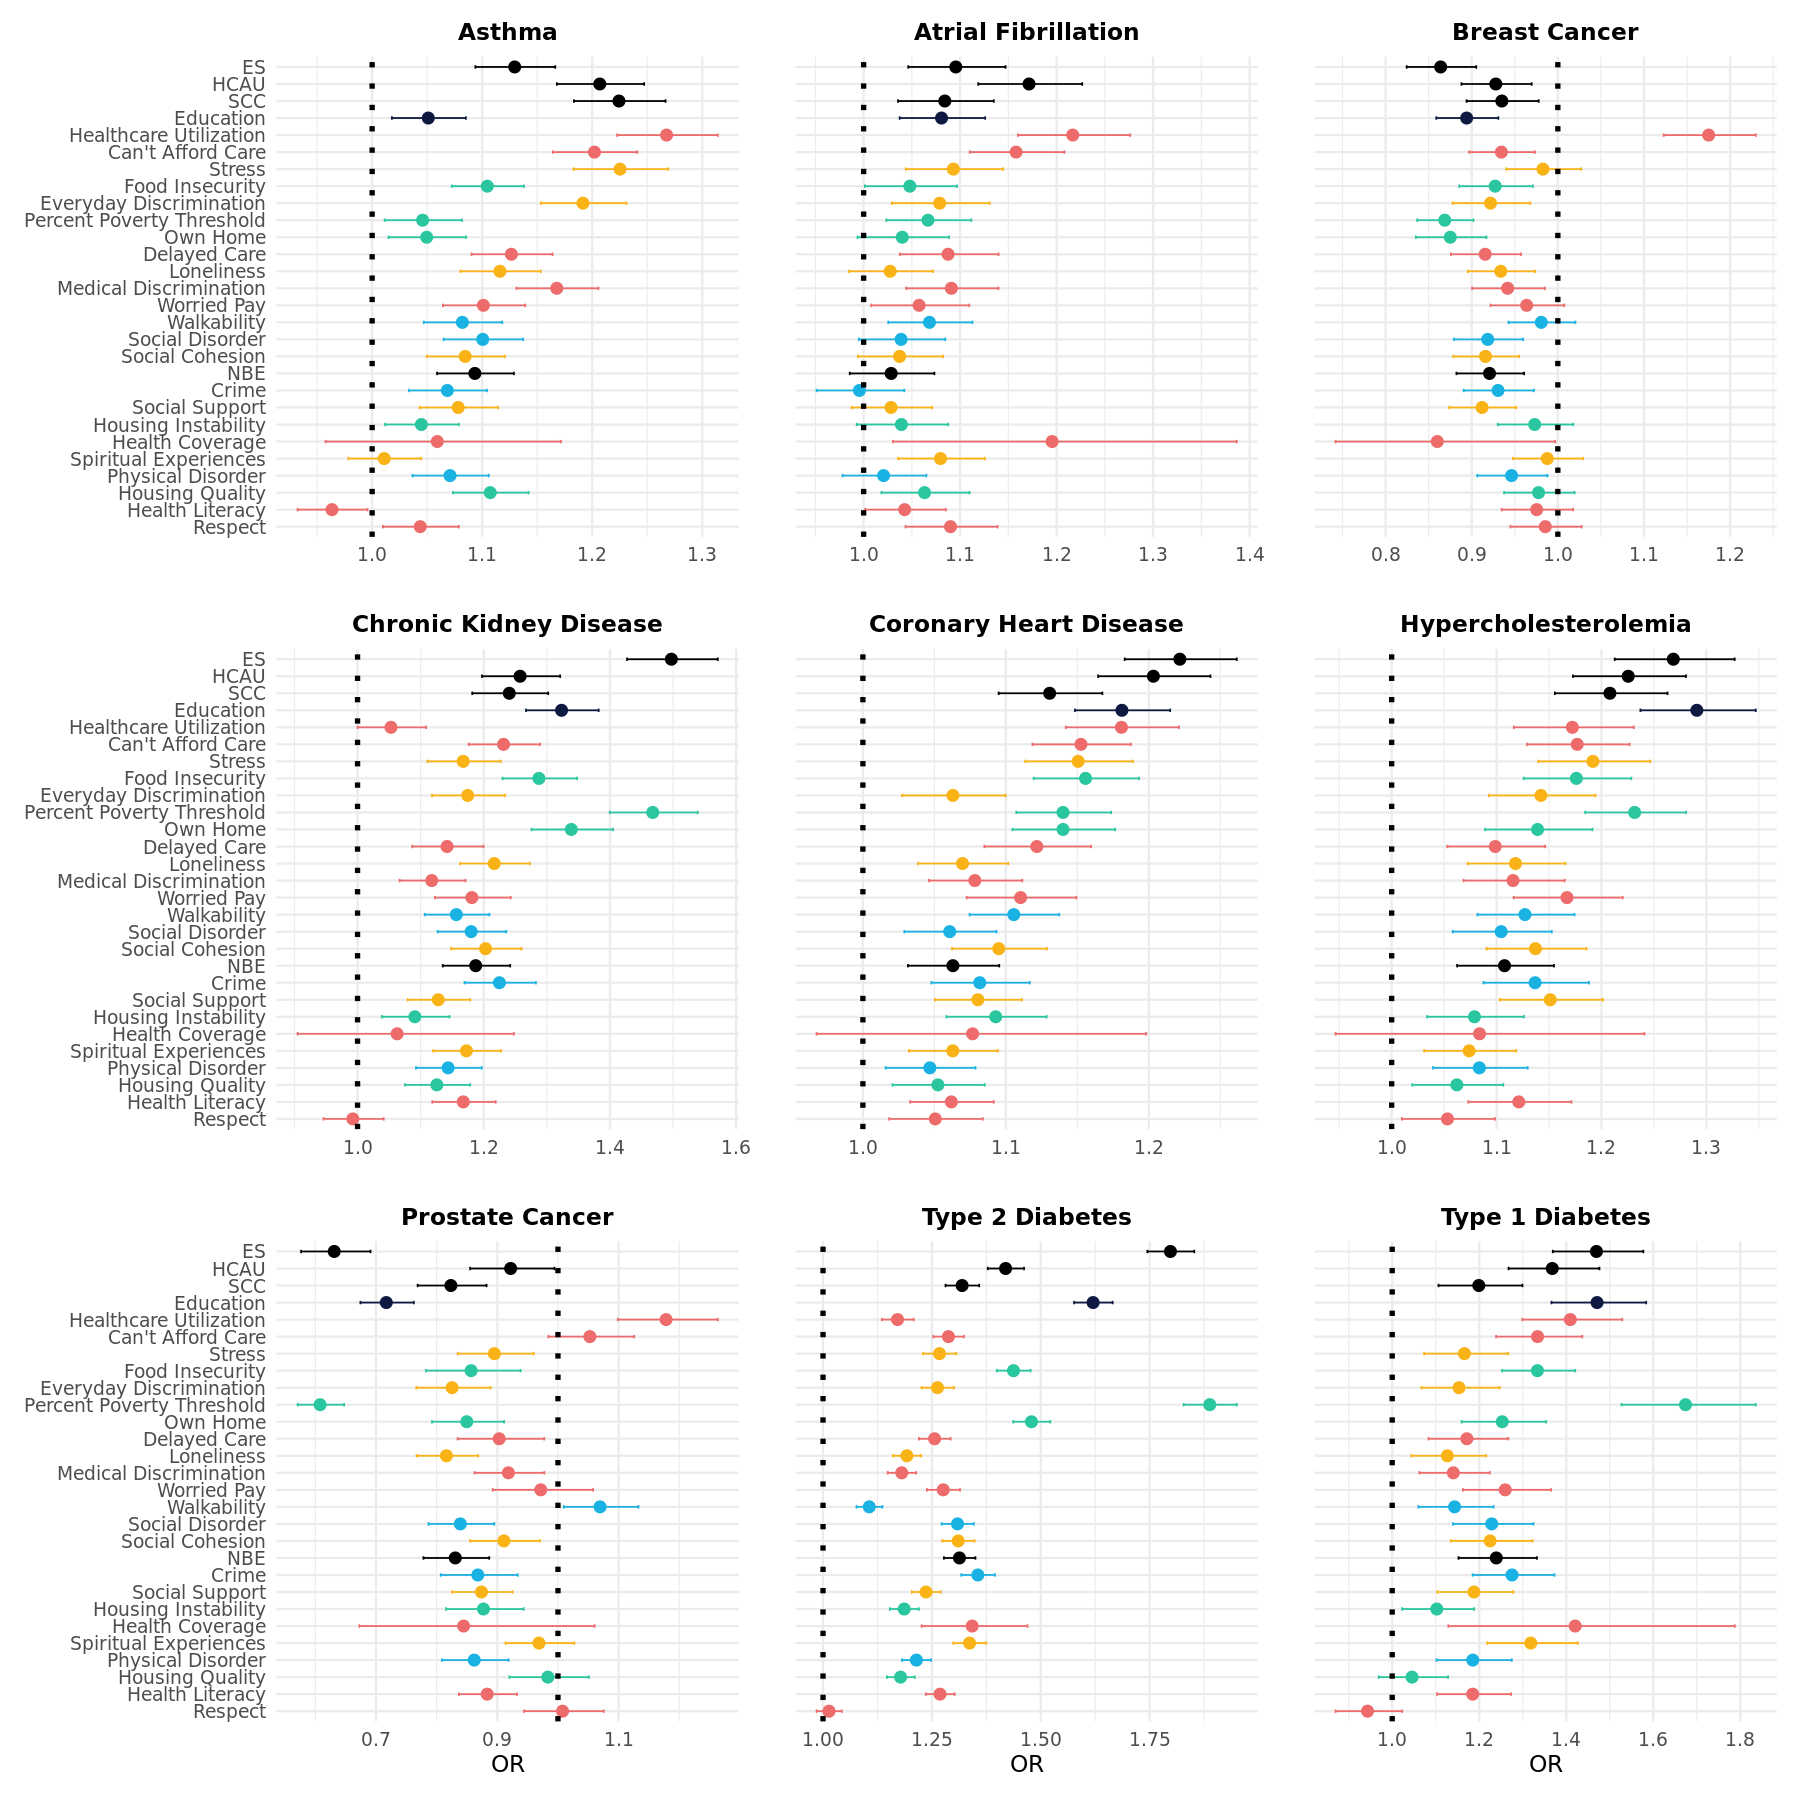

In [16]:
# Compute median OR per domain across all diseases for consistent y-axis ordering
domain_order <- all_results %>%
  group_by(term) %>%
  summarise(median_OR = median(OR, na.rm = TRUE)) %>%
  arrange(median_OR) %>%
  pull(term)

# Custom function to create a plot for a single disease with fixed y-axis order
plot_for_disease_OR <- function(disease_name, data, domain_levels, show_x_label = FALSE) {
  disease_data <- data %>%
    filter(Disease == disease_name) %>%
    mutate(term= factor(term, levels = domain_levels))

  # Dynamically control y-axis text visibility
  y_axis_text <- if (disease_name %in% c("Asthma", "CKD", "ProstateC")) {
    element_text()
  } else {
    element_blank()
  }

  # X-axis label: show "Log-Odds" only on bottom row
  x_axis_label <- if (show_x_label) "OR" else " "

  # Get the renamed disease title
  plot_title <- ifelse(disease_name %in% names(disease_name_mapping),
                       disease_name_mapping[[disease_name]],
                       disease_name)

  # Generate the plot
  ggplot(disease_data, aes(x = OR, y = term, color = Domain)) +
    geom_point(position = position_dodge(width = 0.5), size = 3) +
    geom_errorbarh(aes(xmin = OR_Lower, xmax = OR_Upper),
                   position = position_dodge(width = 0.5), height = 0.2) +
    scale_y_discrete(labels = domain_labels) + 
    scale_color_manual(values = custom_colors, name = "Domain Type") +
    labs(
      title = plot_title,
      x = x_axis_label,
      y = " "
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.y = y_axis_text,
      axis.text.x = element_text(angle = 0, hjust = 0.5),
      legend.position = "none",
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
    ) +
    geom_vline(xintercept = 1, linetype = "dotted", color = "black", size = 1.5)
}

# Order diseases explicitly
unique_diseases <- unique(all_results$Disease)
ncol_grid <- 3  # Set number of columns

# Generate a plot for each disease with consistent y-axis order
plots <- lapply(seq_along(unique_diseases), function(i) {
  show_x_label <- i > (length(unique_diseases) - ncol_grid)  # Show x-axis label only on bottom row
  plot_for_disease_OR(unique_diseases[i], all_results, domain_order, show_x_label)
})

# Combine all plots into a grid
combined_plot <- wrap_plots(plots, ncol = ncol_grid)  # Adjust `ncol` as needed

# Display the combined plot with fixed size
options(repr.plot.width = 15, repr.plot.height = 15)
print(combined_plot)

# Save the combined plot
ggsave("combined_OR_plots_OR_bottom.png", plot = combined_plot, width = 15, height = 15, dpi = 300)


## Plot with unique y-axis ordering and p.value thresholding

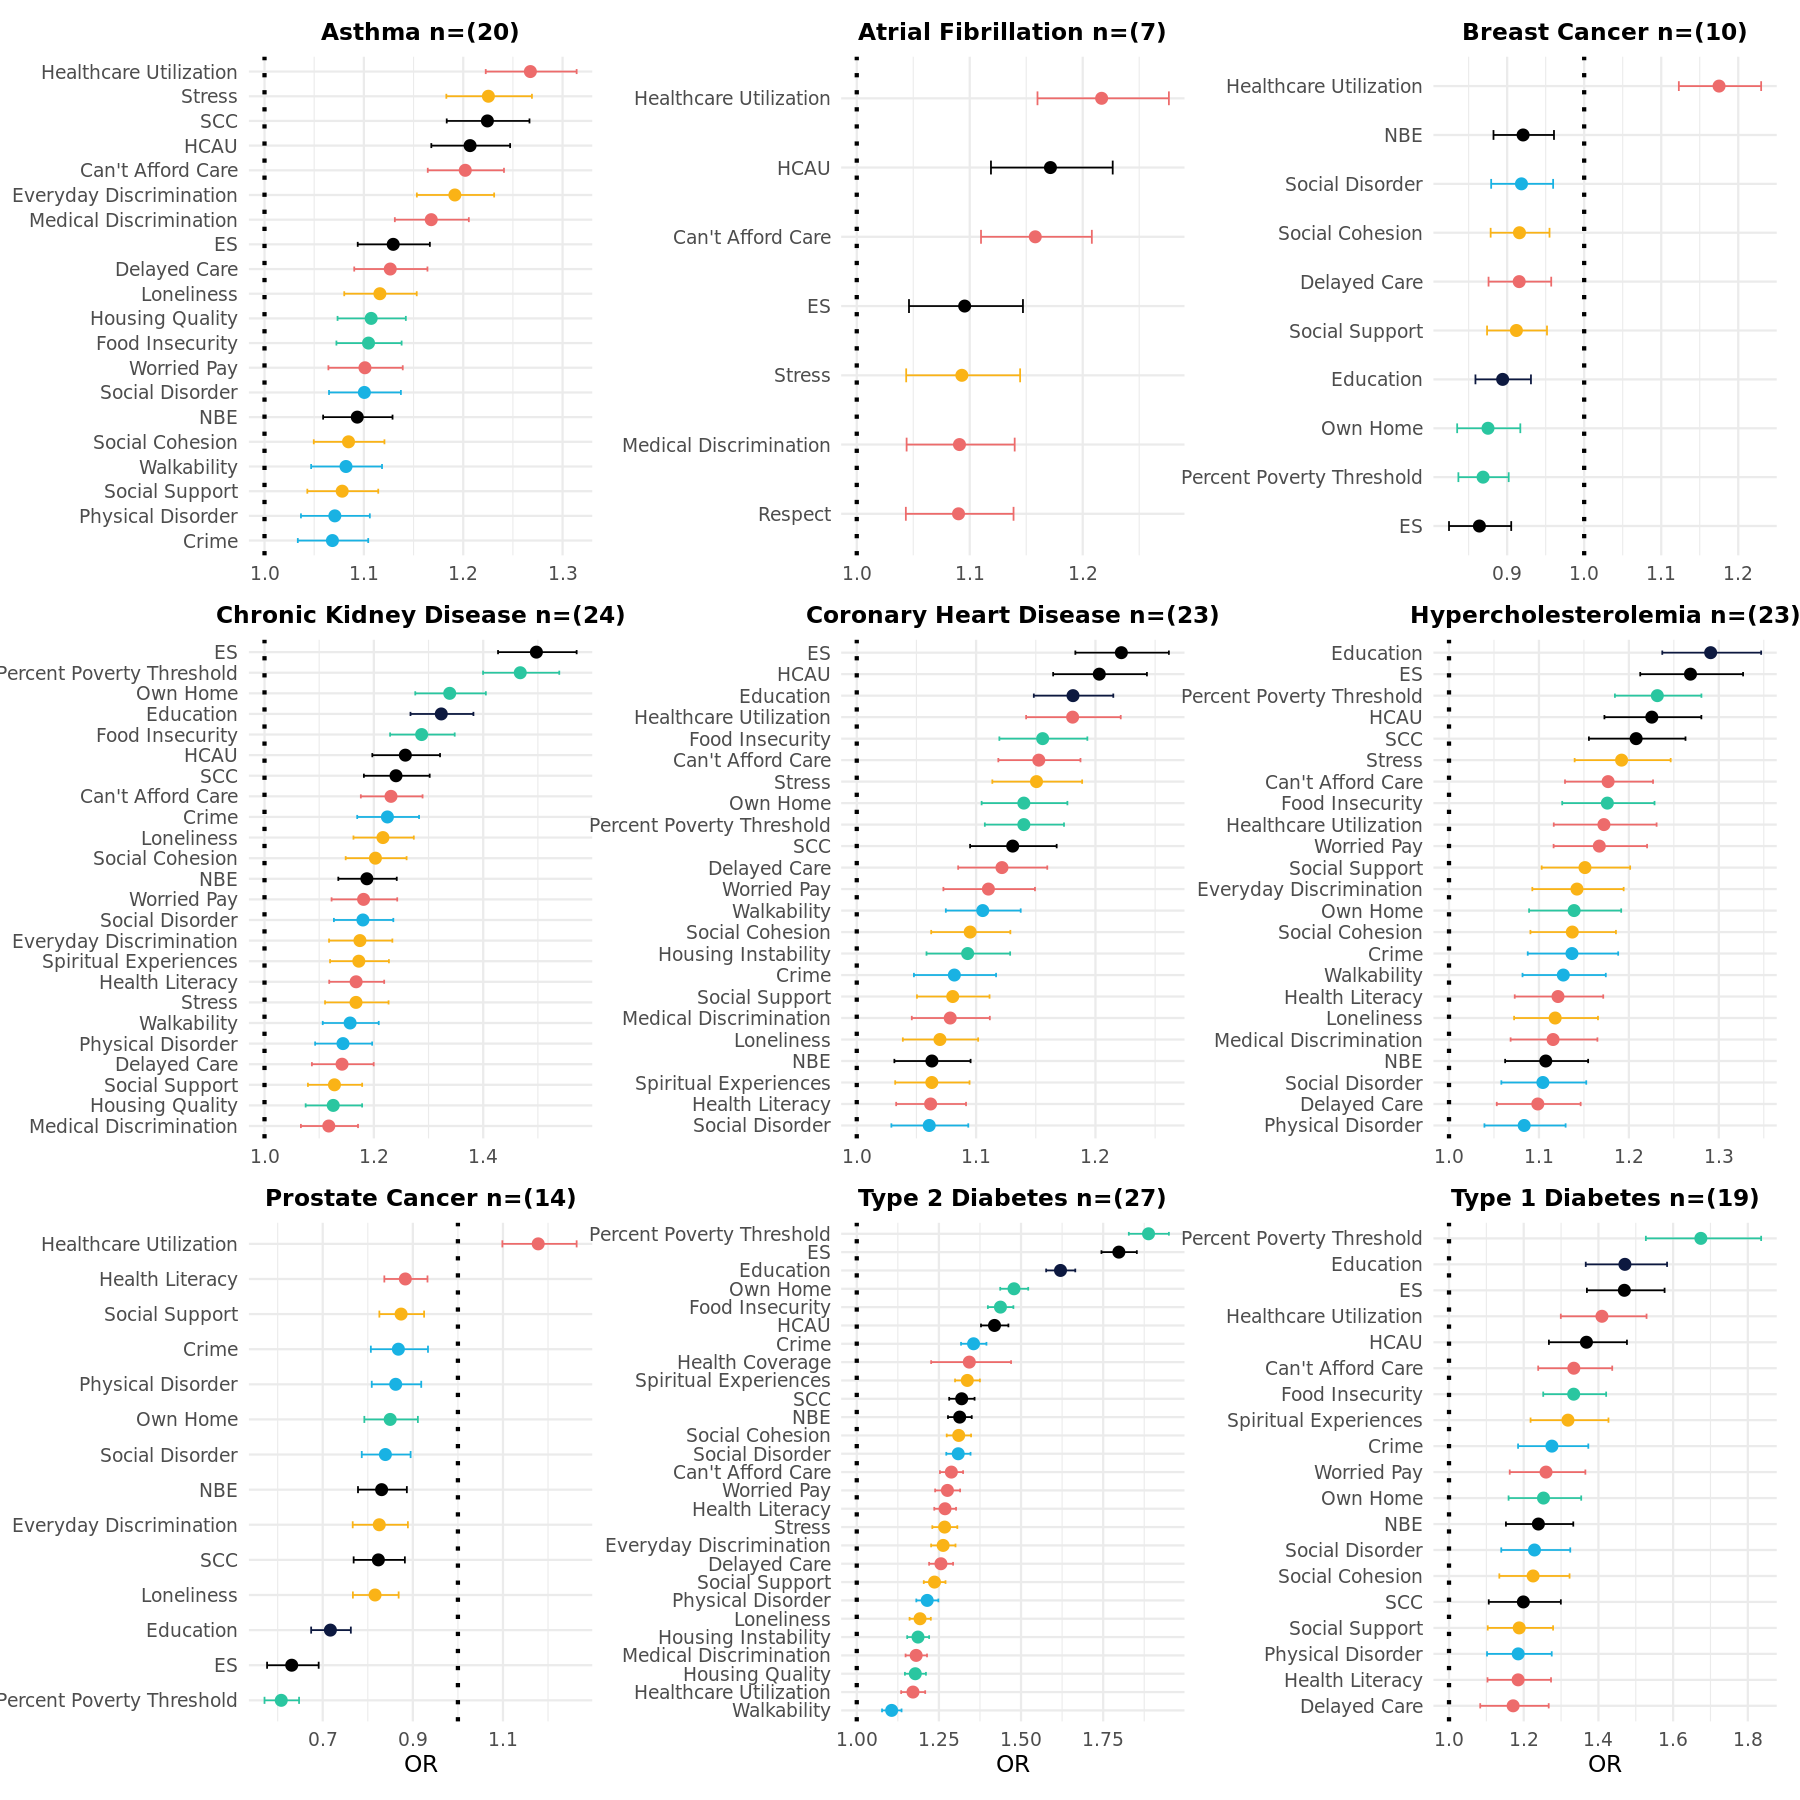

In [17]:
results_filtered<-all_results[all_results$p.value < (.05/(length(all_domains)*length(diseases))), ]


plot_for_disease_OR <- function(disease_name, data, show_x_label = FALSE) {
  disease_data <- data %>%
    filter(Disease == disease_name)
   
    domain_order <- disease_data %>%
      group_by(term) %>%
      arrange(OR) %>%
      pull(term) 
    
    
     disease_data <-  disease_data |> mutate(term= factor(term, levels = domain_order))
    
  x_axis_label <- if (show_x_label) "OR" else NULL

  plot_title <- paste0(disease_name_mapping[[disease_name]], " n=(", nrow(disease_data), ")")

  ggplot(disease_data, aes(x = OR, y = term, color = Domain)) +
    geom_point(size = 3) +
    geom_errorbarh(aes(xmin = OR_Lower, xmax = OR_Upper),
                   height = 0.2) +
    scale_color_manual(values = custom_colors, name = "Domain Type") +
    scale_y_discrete(labels = domain_labels) + 
    labs(
      title = plot_title,
      x = x_axis_label,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.y = element_text(),         # Always show y-axis labels
      axis.text.x = element_text(),
      legend.position = "none",
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
    ) +
    geom_vline(xintercept = 1, linetype = "dotted", color = "black", linewidth = 1.2)
}

plots <- lapply(seq_along(unique_diseases), function(i) {
  show_x_label <- i > (length(unique_diseases) - ncol_grid)
  plot_for_disease_OR(unique_diseases[i], results_filtered, show_x_label)
})


# Combine all plots into a grid
combined_plot <- wrap_plots(plots, ncol = ncol_grid)  # Adjust `ncol` as needed

# Display the combined plot with fixed size
options(repr.plot.width = 15, repr.plot.height = 15)
print(combined_plot)

# Save the combined plot
ggsave("combined_OR_plots_OR_bottom.png", plot = combined_plot, width = 15, height = 15, dpi = 300)


## Compare individual components to Factor Domains

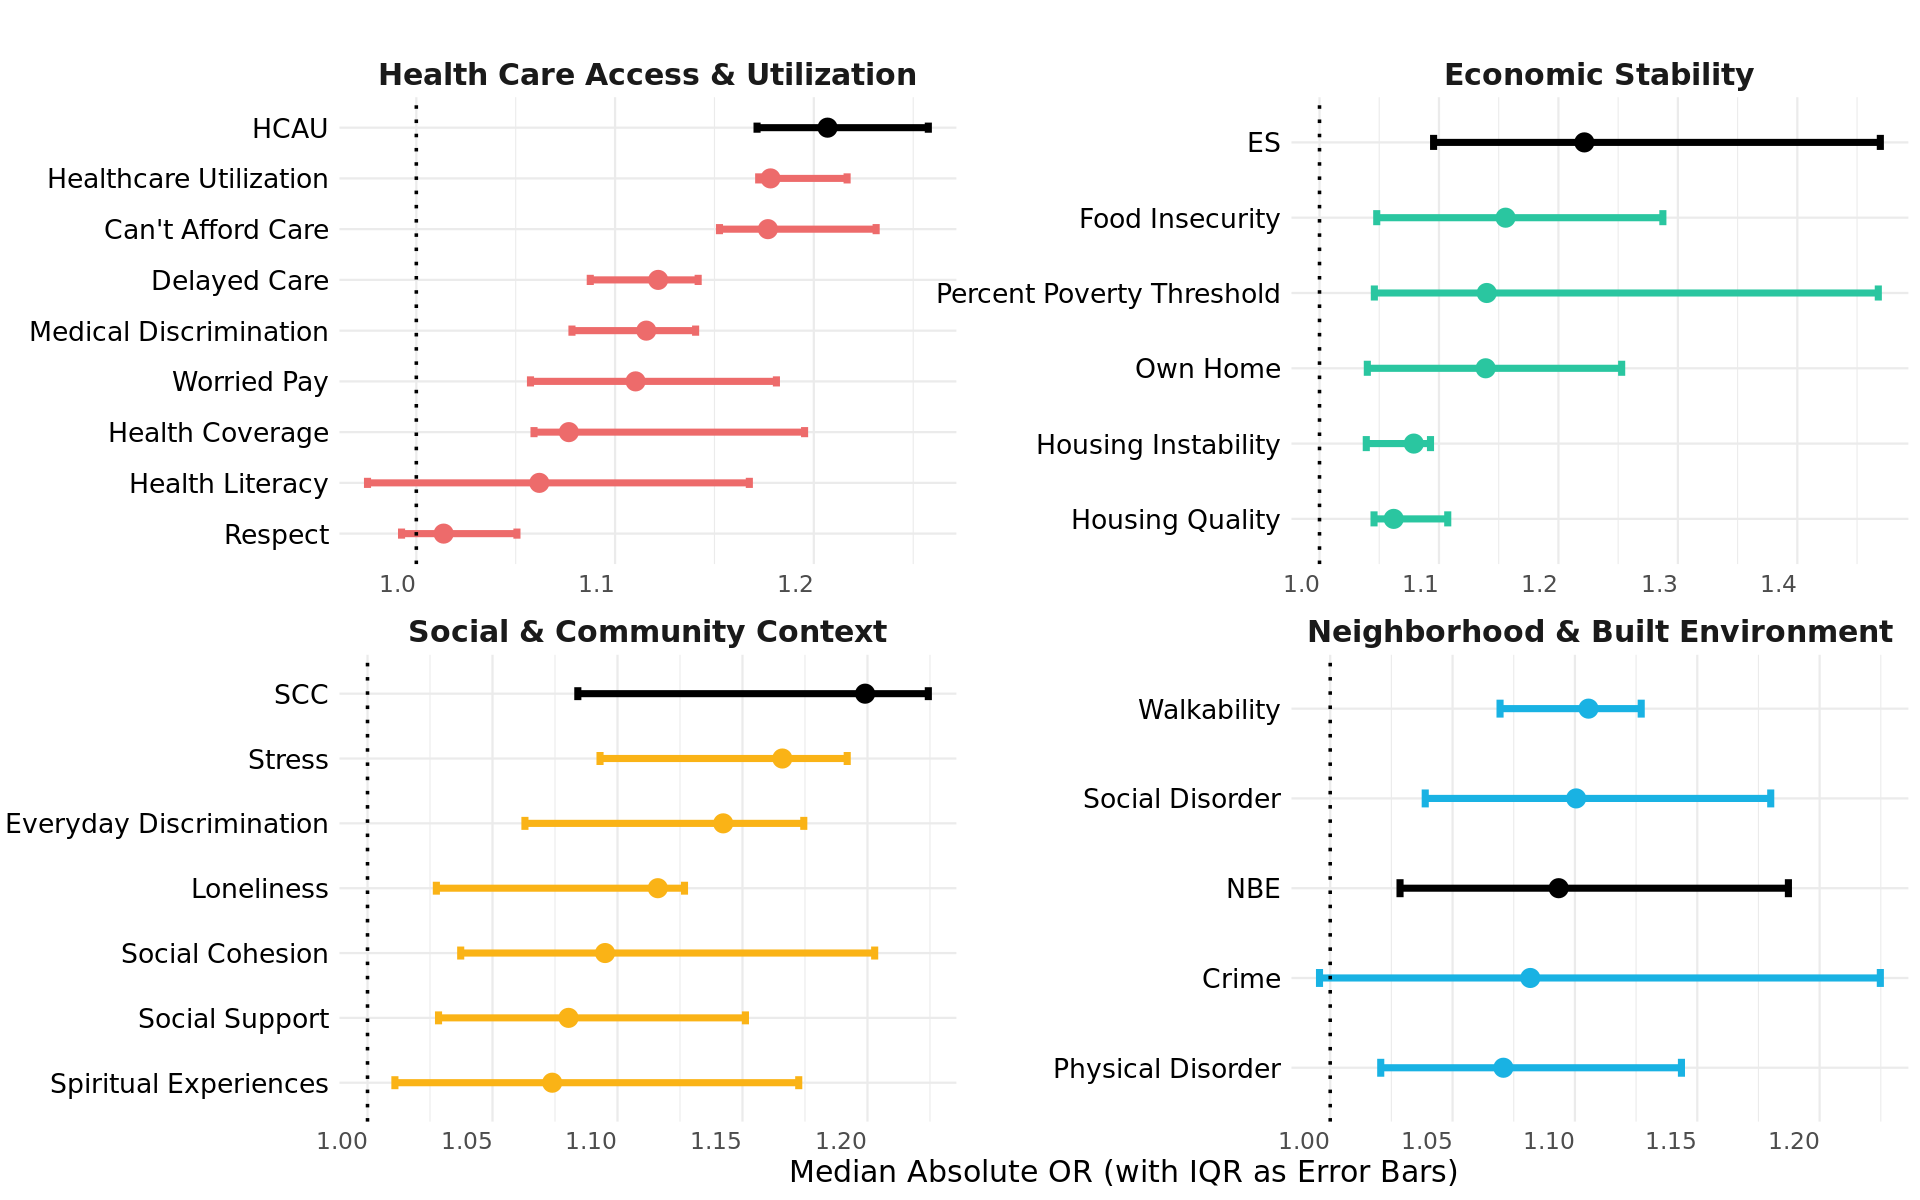

In [18]:
# Custom mapping for renaming diseases
disease_name_mapping <- c(
  "Asthma" = "Asthma",
  "Afib" = "Atrial Fibrillation",
  "BreastC" = "Breast Cancer",
  "CKD" = "Chronic Kidney Disease",
  "CHD" = "Coronary Heart Disease", 
  "HyperC" = "Hypercholesterolemia",
  "ProstateC" = "Prostate Cancer",
  "t2d" = "Type 2 Diabetes",
  "t1d" = "Type 1 Diabetes"
)

# Add the Domain column to the dataframe
all_results <- all_results %>%
  mutate(
    Domain = case_when(
      term %in% c("SCC", SCC) ~ "SCC",
      term %in% c("NBE", NBE) ~ "NBE",
      term %in% c("ES", ES) ~ "ES",
      term %in% c("HCAU", HCAU) ~ "HCAU",
      term %in% education ~ "Education",
      TRUE ~ "SDOH"  # Fallback for domains not in any list
    )
  )

all_results <- all_results %>%
  mutate(
    domain_subtype = case_when(
      term %in% SCC ~ "SCC",
      term %in% NBE~ "NBE",
      term %in% ES ~ "ES",
      term %in% HCAU ~ "HCAU",
      term %in% c("SCC", "NBE", "ES", "HCAU", "Education") ~ "Domain",
      TRUE ~ "SDOH"  # Fallback for domains not in any list
    )
  )

# Set levels of the Domain factor
all_results$Domain <- factor(
  all_results$Domain,
  levels = c("HCAU", "ES", "SCC", "NBE", "Education")
)

# ✅ Custom labels for Domain
Domain_labels <- c(
  "HCAU" = "Health Care Access & Utilization",
  "ES" = "Economic Stability",
  "SCC" = "Social & Community Context",
  "NBE" = "Neighborhood & Built Environment",
  "Education" = "Education"
)

# Custom colors for Domain

custom_colors <- c(
  "Domain" = "black",
  "HCAU" = "#ED6B6B",
  "ES" = "#2AC6A0",
  "Education" = "#0D1940",
  "SCC" = "#FAB316",
  "NBE" = "#19B2E3"
)

# ✅ Compute median absolute log-odds across diseases, excluding 'education' and 'SDOH'
median_OR <- all_results %>%
  filter(!term %in% c("Education", "SDOH")) %>%  # Remove specified domains
  group_by(term, domain_subtype, Domain) %>%
  summarise(
    median_abs_OR = median(abs(OR), na.rm = TRUE),
    lower_bound = quantile(abs(OR), 0.25, na.rm = TRUE),  # Lower quartile for error bar
    upper_bound = quantile(abs(OR), 0.75, na.rm = TRUE),  # Upper quartile for error bar
    .groups = "drop"
  )



# ✅ Plot as a forest plot faceted by renamed Domain
forest_plot <- ggplot(median_OR, aes(x = median_abs_OR, y = reorder(term, median_abs_OR), color = domain_subtype)) +
  geom_point(size = 5) +  # Points for median absolute Odds Ratios
  geom_errorbarh(aes(xmin = lower_bound, xmax = upper_bound), height = 0.2, size=2) +  # Horizontal error bars
  scale_color_manual(values = custom_colors) +
  scale_y_discrete(labels = domain_labels) +  # Apply clean labels to the Domain axis
  facet_wrap(~ Domain, scales = "free", ncol = 2, labeller = as_labeller(Domain_labels)) +  # Updated facet titles
  labs(
    x = "Median Absolute OR (with IQR as Error Bars)",
    y = " ",
    title = " "  # Add plot title
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_text(size = 18),            # Increase x-axis title size
    axis.title.y = element_text(size = 16, face = "bold"),            # Increase y-axis title size
    axis.text.x = element_text(size = 14, hjust = 1),     # Increase x-axis text size
    axis.text.y = element_text(size = 16, color="black"),                            # Increase y-axis text size
    strip.text = element_text(size = 18, face = "bold"),              # Increase facet title size
    legend.position = "none"                                          # Hide legend
  ) +
  geom_vline(xintercept = 1, linetype = "dotted", color = "black", size = 1)  # Reference line at OR = 1

# ✅ Display the forest plot
options(repr.plot.width = 16, repr.plot.height = 10)
print(forest_plot)

# ✅ Save the forest plot
ggsave("forest_plot_median_abs_OR_renamed_domains.png", plot = forest_plot, width = 16, height = 10, dpi = 300)


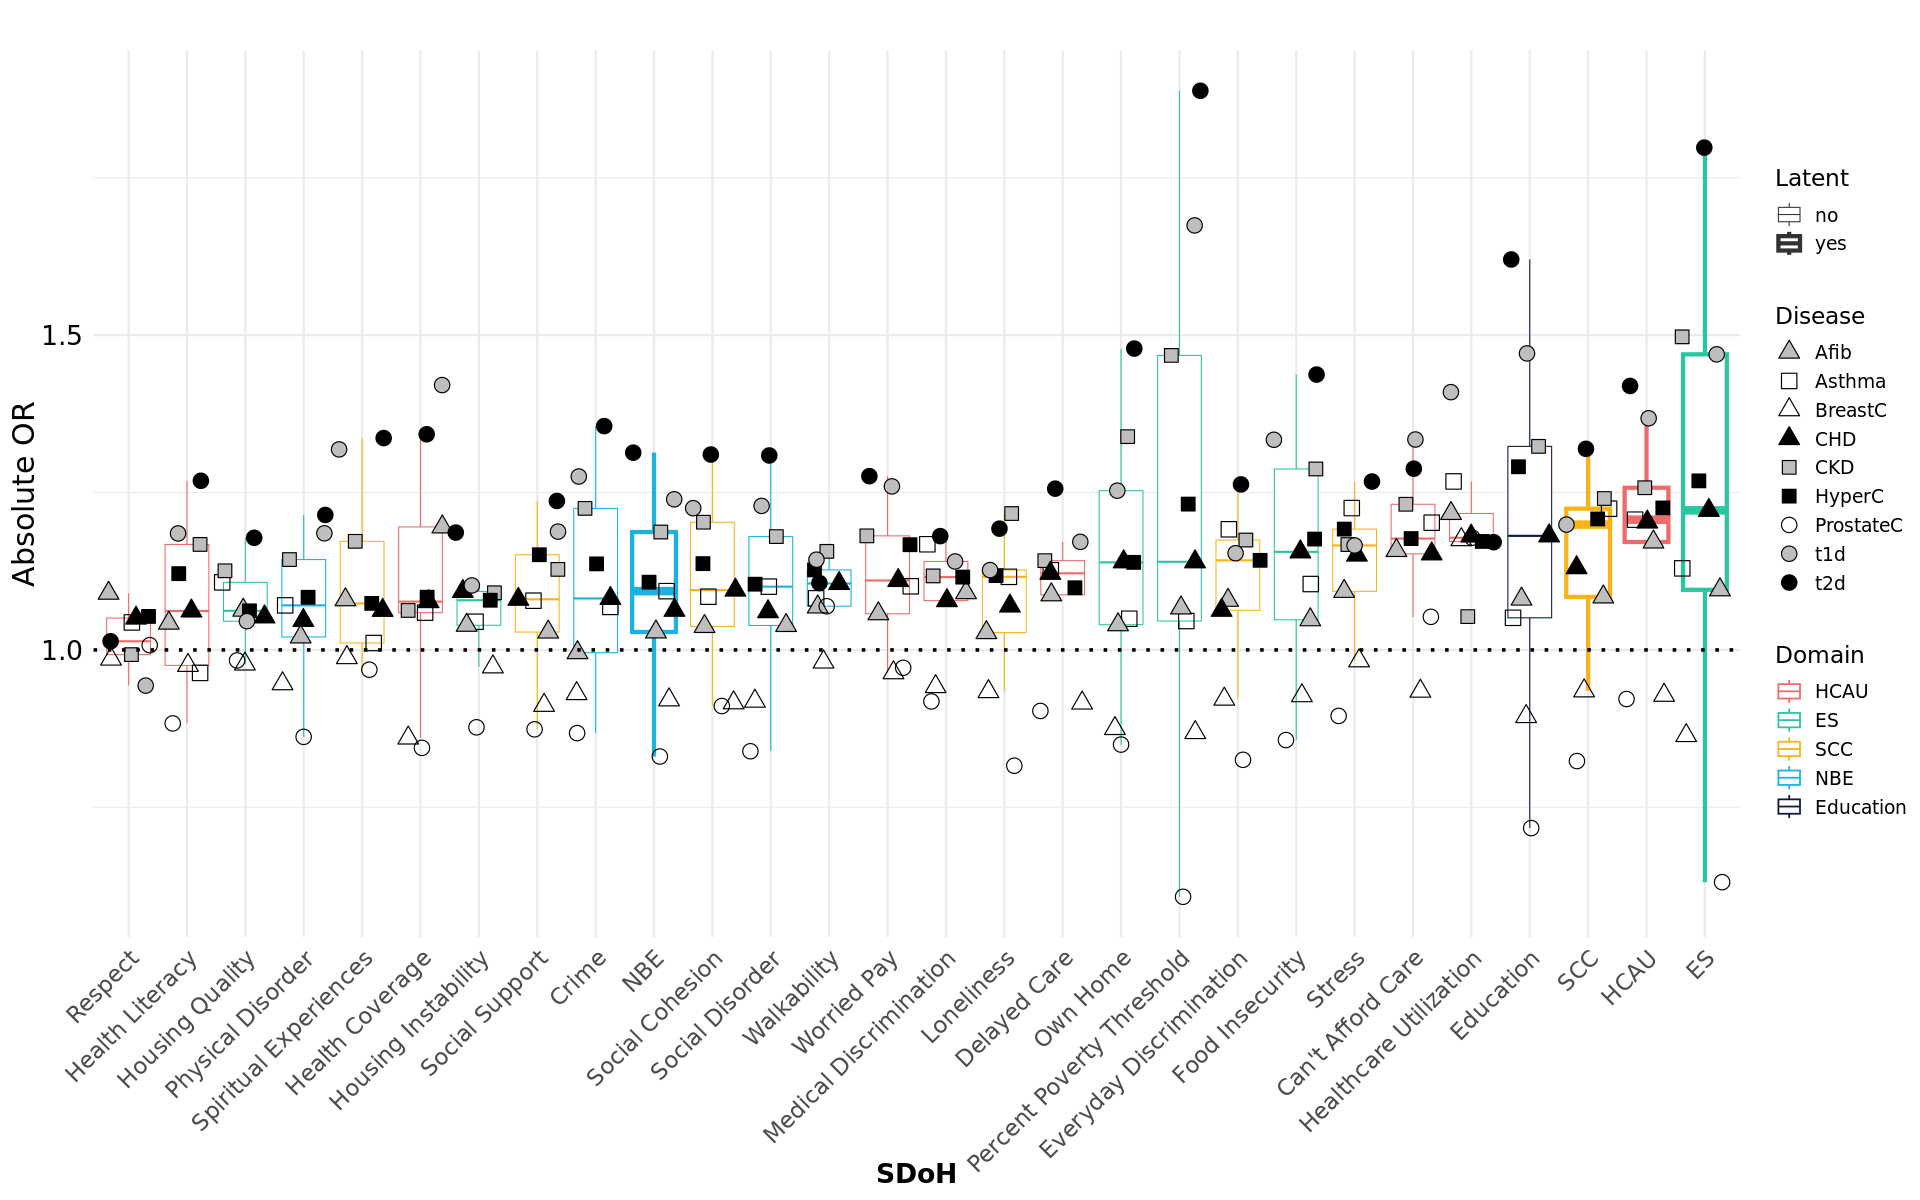

In [19]:
library(dplyr)
library(ggplot2)


median_OR <- all_results %>%
  group_by(term, domain_subtype, Domain) %>%
  summarise(
    median_abs_OR = median(abs(OR), na.rm = TRUE),
    lower_bound = quantile(abs(OR), 0.25, na.rm = TRUE),  # Lower quartile for error bar
    upper_bound = quantile(abs(OR), 0.75, na.rm = TRUE),  # Upper quartile for error bar
    .groups = "drop"
  )

# Step 1: Compute median absolute ORs for ordering
term_order <- all_results %>%
  group_by(term) %>%
  summarise(median_abs_OR = median(abs(OR), na.rm = TRUE), .groups = "drop")

# Step 2: Join to main data for plotting
results_ordered <- all_results %>%
  left_join(term_order, by = "term") %>%
  mutate(term = reorder(term, median_abs_OR))

# Step 0: Add a column to indicate which SDoH terms should be hatched
results_ordered$Latent <- ifelse(results_ordered$term %in% c("HCAU", "SDOH", "SCC",
                                                                  "NBE", "ES"), "yes", "no")  # example
results_ordered <- results_ordered %>% distinct()

# Step 3: Plot
ggplot(results_ordered, aes(x = term, y = abs(OR))) +
  
  # Boxplot layer (colored by highlight alpha)
  geom_boxplot(
  aes(color = Domain, linewidth = Latent),
  outlier.shape = NA,
      alpha = 1
  ) +
   
  # Custom point layer with shape and fill for Disease
  geom_jitter(
    aes(shape = Disease, fill = Disease),
    size = 4, color = "black"
  ) +

  # Manual shape settings for each disease
  scale_shape_manual(values = c(
    "t2d" = 21, # circle filled
    "ProstateC" = 1, # circle open
    "t1d" = 21, # circle filled
    "HyperC" = 22, # square filled
    "Asthma" = 0, # square open
    "CKD" = 22, # square filled
    "CHD" = 24, # triangle filled
    "BreastC" = 2, # triangle open
    "Afib" = 24 # triangle filled
  )) +

  # Manual fill colors for Disease (use NA for open)
  scale_fill_manual(values = c(
    "t2d" = "black",
    "ProstateC" = NA,
    "t1d" = "grey",
    "HyperC" = "black",
    "Asthma" = NA,
    "CKD" = "grey",
    "CHD" = "black",
    "BreastC" = NA,
    "Afib" = "grey"
  )) +

  # Color scale for jitter points (or override with your own palette)
  scale_color_manual(values = custom_colors) +

  # Custom linewidth for highlighted vs not highlighted boxplots
  scale_linewidth_manual(values = c("yes" = 1.2, "no" = 0.3)) +  # adjust as needed

  # Labels and formatting
  labs(
    x = "SDoH",
    y = "Absolute OR",
    title = ""
  ) +
  scale_x_discrete(labels = domain_labels) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 18),
    axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 16, color = "black"),
    strip.text = element_text(size = 18, face = "bold")
    #legend.position = "none"
  ) +

  # Horizontal reference line
  geom_hline(yintercept = 1, linetype = "dotted", color = "black", size = 1)



# Area-level

## Set up

In [20]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'SES_cohort.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
zip_code_socioeconomic_df  <- read_csv(name_of_file_in_bucket)


character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [21]:
all_domains<-c(domains, "no_high_school_education", "lower_median_income", "no_health_insurance",  "vacant_housing", "deprivation_index")
area_level<-c("no_high_school_education", "lower_median_income", "no_health_insurance",  "vacant_housing", "deprivation_index")


In [22]:
#compare within same sample
merged_data<-merge(merged_data, zip_code_socioeconomic_df[,c(area_level, "person_id")], on="person_id", how="inner")


In [23]:
# Create combinations of diseases and domains
combinations <- expand_grid(disease = diseases, domain = all_domains)

# Fit models
results <- combinations %>%
  mutate(
    model_syntax = map2(disease, domain, generate_model),
    model_results = pmap(list(model_syntax, list(merged_data), disease, domain), fit_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

# Add domain type
results <- results %>%
  dplyr::mutate(
    Domain = dplyr::case_when(
      term %in% domains ~ "Individual-level",
      term %in% area_level ~ "Area-level",
      TRUE ~ "SDOH"
    )
  ) %>% 
    filter(term %in% all_domains)

# Preview results
print(head(results))


# A tibble: 6 × 12
  term         estimate std.error statistic  p.value SD_predictor    OR OR_Lower
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>        <dbl> <dbl>    <dbl>
1 SCC            0.202     0.0174     11.7  1.93e-31        1.02  1.22     1.18 
2 NBE            0.0893    0.0163      5.48 4.32e- 8        1.01  1.09     1.06 
3 ES             0.122     0.0164      7.43 1.08e-13        1.03  1.13     1.09 
4 HCAU           0.188     0.0168     11.2  3.21e-29        1.03  1.21     1.17 
5 Education      0.0498    0.0163      3.05 2.28e- 3        1.00  1.05     1.02 
6 no_high_sch…  -0.158     0.0214     -7.39 1.44e-13        0.802 0.854    0.819
# ℹ 4 more variables: OR_Upper <dbl>, Disease <chr>, SDoH_Variable <chr>,
#   Domain <chr>


## Plot Individual-level vs Area-level

In [24]:
domain_order

[1] "Respect"                   "Health.Literacy"          
 [3] "Housing.Quality"           "Physical.Disorder"        
 [5] "Spiritual.Experiences"     "Health.Coverage"          
 [7] "Housing.Instability"       "Social.Support"           
 [9] "Crime"                     "NBE"                      
[11] "Social.Cohesion"           "Social.Disorder"          
[13] "Walkability"               "Worried.Pay"              
[15] "Medical.Discrimination"    "Loneliness"               
[17] "Delayed.Care"              "Own.Home"                 
[19] "Percent.Poverty.Threshold" "Everyday.Discrimination"  
[21] "Food.Insecurity"           "Stress"                   
[23] "Can.t.afford.care"         "Healthcare.Utilization"   
[25] "Education"                 "SCC"                      
[27] "HCAU"                      "ES"

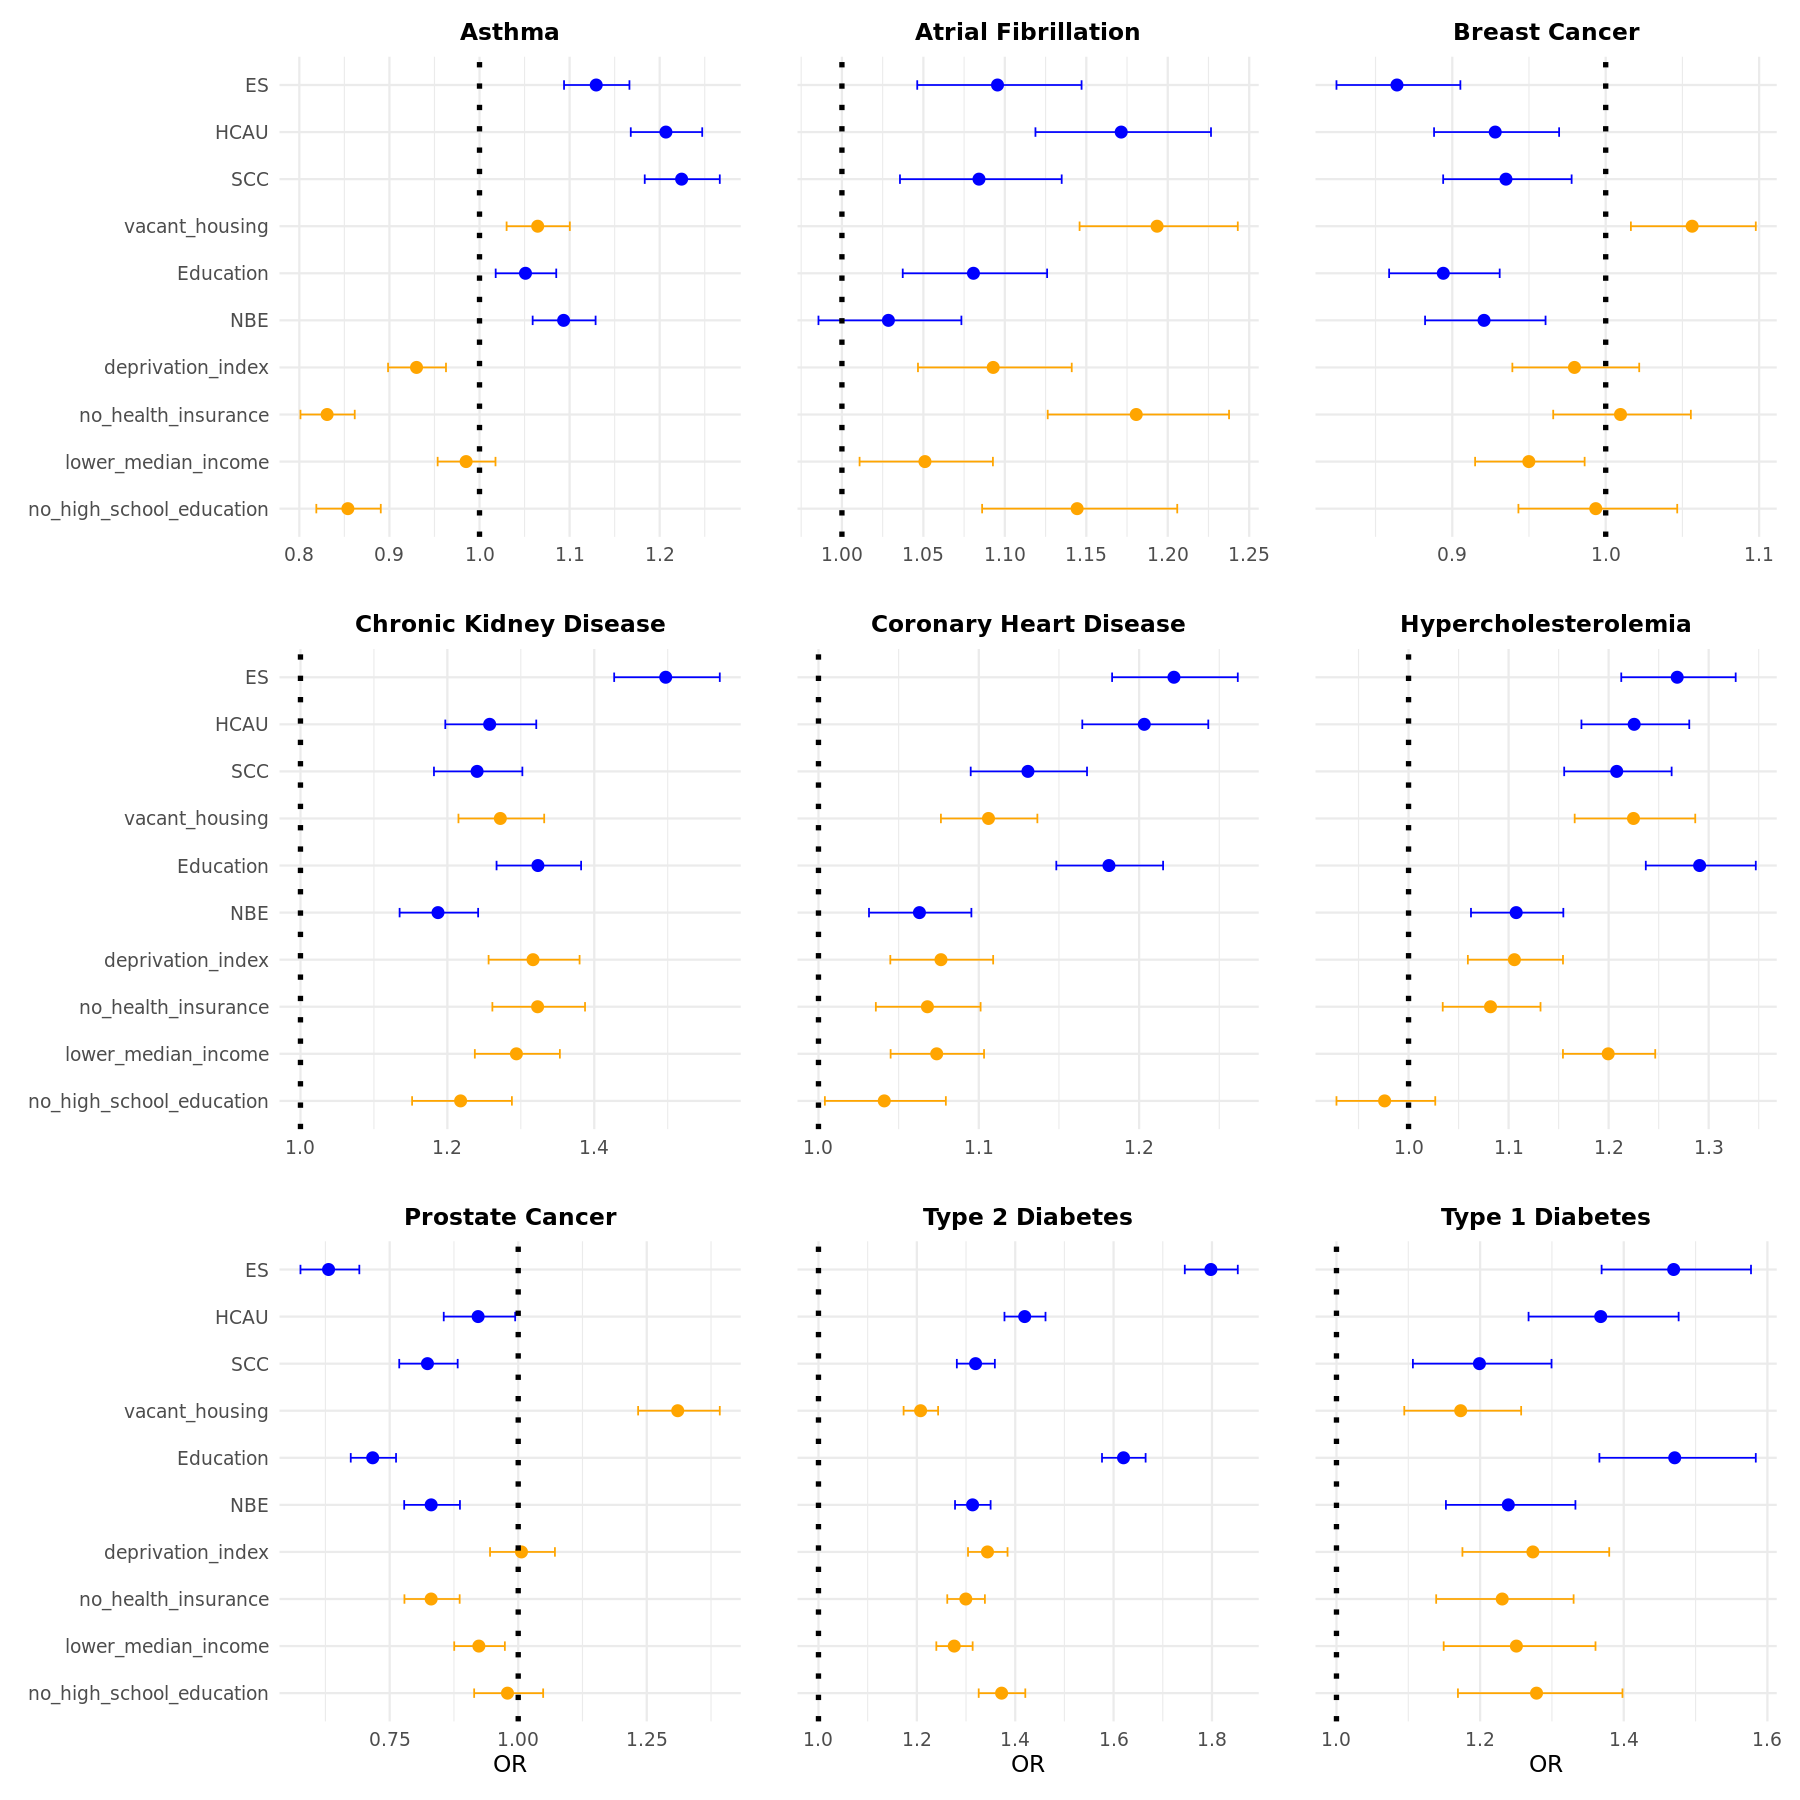

In [25]:
# Compute median OR per domain across all diseases for consistent y-axis ordering
domain_order <- results %>%
  group_by(term) %>%
  summarise(median_OR = median(abs(OR), na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(median_OR)) %>%
  pull(term)

# Set the levels of the Domain factor
results$Domain <- factor(
  results$Domain,
  levels = c("Individual-level", "Area-level")
)

# Custom colors for Domain
custom_colors <- c(
  "Individual-level" = "blue",
  "Area-level" = "orange"
)


# Custom function to create a plot for a single disease with fixed y-axis order
plot_for_disease_OR <- function(disease_name, data, domain_levels, show_x_label = FALSE) {
  disease_data <- data %>%
    filter(Disease == disease_name) 
    
     disease_data <-  disease_data |> mutate(term= factor(term, levels = rev(domain_order)))
    

  # Dynamically control y-axis text visibility
  y_axis_text <- if (disease_name %in% c("Asthma", "CKD", "ProstateC")) {
    element_text()
  } else {
    element_blank()
  }

  # X-axis label: show "Log-Odds" only on bottom row
  x_axis_label <- if (show_x_label) "OR" else " "

  # Get the renamed disease title
  plot_title <- ifelse(disease_name %in% names(disease_name_mapping),
                       disease_name_mapping[[disease_name]],
                       disease_name)

  # Generate the plot
  ggplot(disease_data, aes(x = OR, y = term, color = Domain)) +
    geom_point(position = position_dodge(width = 0.5), size = 3) +
    geom_errorbarh(aes(xmin = OR_Lower, xmax = OR_Upper),
                   position = position_dodge(width = 0.5), height = 0.2) +
    scale_color_manual(values = custom_colors, name = "Domain Type") +
    labs(
      title = plot_title,
      x = x_axis_label,
      y = " "
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.y = y_axis_text,
      axis.text.x = element_text(angle = 0, hjust = 0.5),
      legend.position = "none",
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
    ) +
    geom_vline(xintercept = 1, linetype = "dotted", color = "black", size = 1.5)
}

# Order diseases explicitly
unique_diseases <- unique(results$Disease)
ncol_grid <- 3  # Set number of columns in the grid

# Generate a plot for each disease with consistent y-axis order
plots <- lapply(seq_along(unique_diseases), function(i) {
  # Show x-axis label only on the bottom row
  show_x_label <- i > (length(unique_diseases) - ncol_grid)
  plot_for_disease_OR(unique_diseases[i], results, domain_order, show_x_label)
})

# Combine all plots into a single grid
combined_plot <- wrap_plots(plots, ncol = ncol_grid)

# Display the combined plot with fixed size
options(repr.plot.width = 15, repr.plot.height = 15)
print(combined_plot)

# Save the combined plot
ggsave("combined_OR_plots_OR_bottom_fixed.png", plot = combined_plot, width = 15, height = 15, dpi = 300)



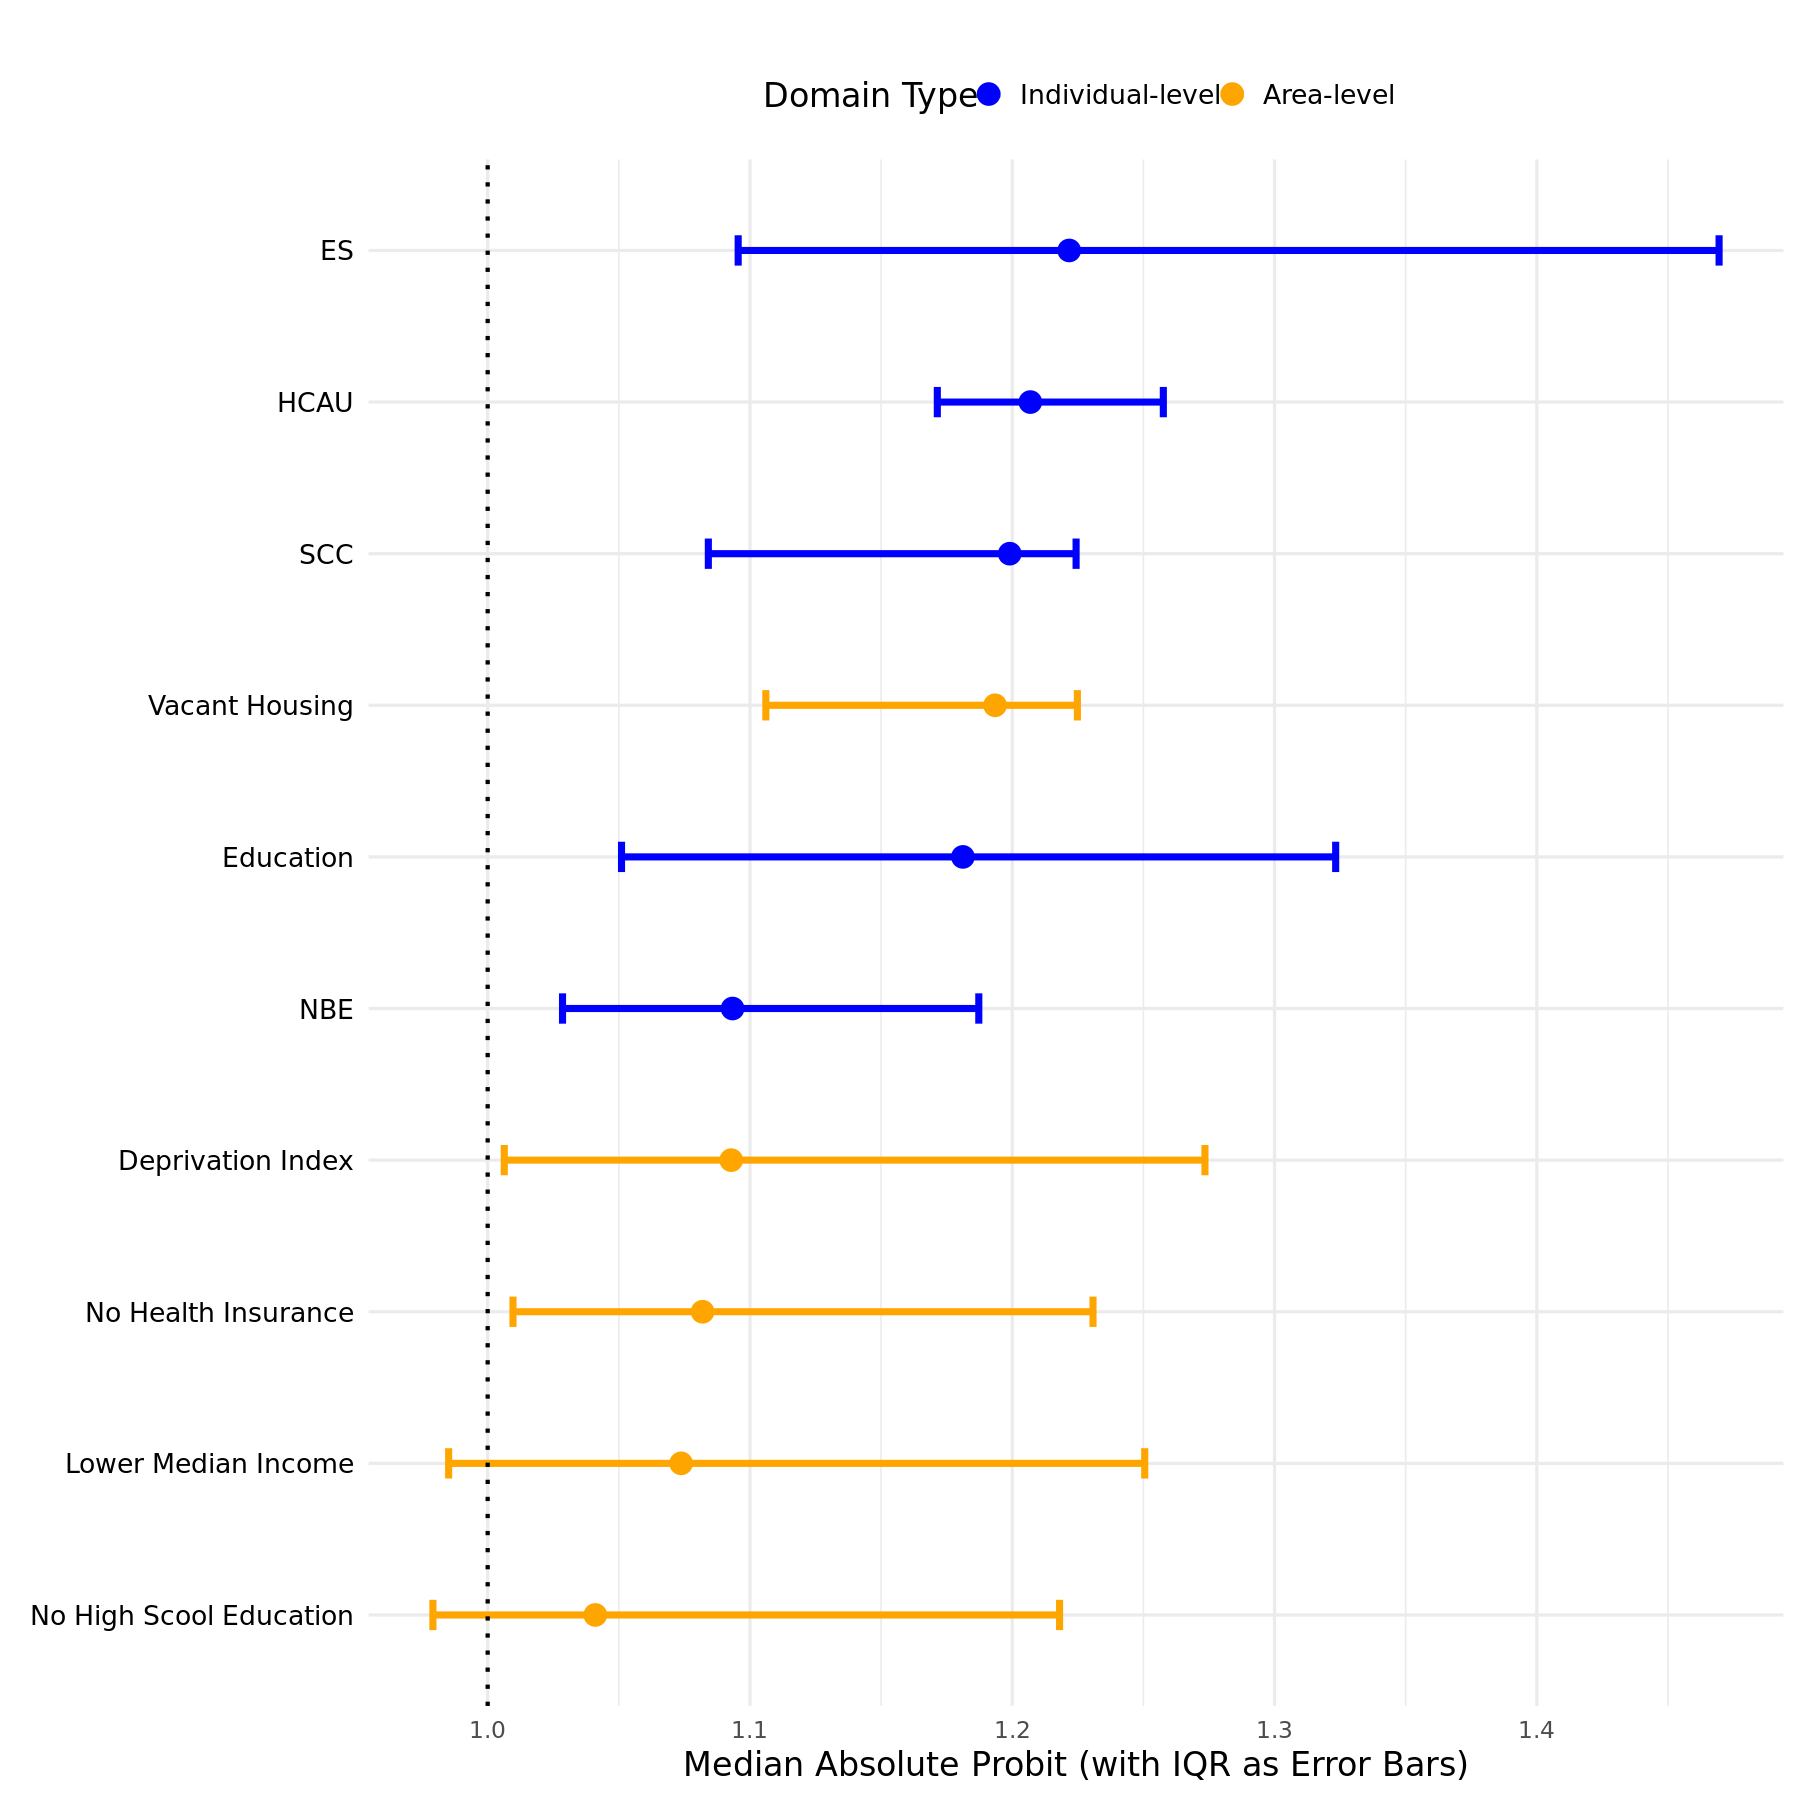

In [26]:
# Compute median of absolute log-odds and IQR per domain across all diseases
domain_summary <- results %>%
  group_by(term, Domain) %>%
  summarise(
    median_abs_OR = median(abs(OR), na.rm = TRUE),
    iqr_lower = quantile(abs(OR), 0.25, na.rm = TRUE),
    iqr_upper = quantile(abs(OR), 0.75, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    term = factor(term, levels = term[order(median_abs_OR)])
  )

# Custom colors for Domain
custom_colors <- c(
  "Individual-level" = "blue",
  "Area-level" = "orange"
)

options(repr.plot.width = 15, repr.plot.height = 15)

# Generate the plot
overall_compare_plot <- ggplot(domain_summary, aes(x = median_abs_OR, y = term, color = Domain)) +
  geom_point(size = 6) +
  geom_errorbarh(aes(xmin = iqr_lower, xmax = iqr_upper), height = 0.2, size = 2) +
  scale_color_manual(values = custom_colors, name = "Domain Type") +
  scale_y_discrete(
    labels = c(
      "vacant_housing" = "Vacant Housing",
        "lower_median_income" = "Lower Median Income",
        "no_health_insurance" = "No Health Insurance",
        "Education" = "Education",
        "no_high_school_education" = "No High Scool Education",
        "deprivation_index" = "Deprivation Index"
    )
  ) +
  labs(
    title = " ",
    x = "Median Absolute Probit (with IQR as Error Bars)",
    y = " "
  ) +
  theme_minimal(base_size = 20) +
  theme(
    axis.text.y = element_text(size = 16, color="black"),
    axis.text.x = element_text(size = 14),
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
      legend.text = element_text(size = 16),
    legend.position = "top"
  ) +
  geom_vline(xintercept = 1, linetype = "dotted", color = "black", size = 1.2)

overall_compare_plot

# Save the plot
ggsave("median_abs_OR_iqr_plot.png", width = 10, height = 10, dpi = 300)

## All measures

## Set Up

In [27]:
# Custom colors for Domain
custom_colors <- c(
  "Area-level" = "black",
  "HCAU" = "#ED6B6B",
  "ES" = "#2AC6A0",
  "Education" = "blue",
  "SCC" = "#FAB316",
  "NBE" = "#19B2E3"
)


# ✅ Clean labels for the Domain names
domain_labels <- c(
  "Social.Support" = "Social Support",
  "Loneliness" = "Loneliness",
  "Social.Cohesion" = "Social Cohesion",
  "Everyday.Discrimination" = "Everyday Discrimination",
  "Stress" = "Stress",
  "Spiritual.Experiences" = "Spiritual Experiences",
  "Crime" = "Crime",
  "Physical.Disorder" = "Physical Disorder",
  "Social.Disorder" = "Social Disorder",
  "Walkability" = "Walkability",
  "Own.Home" = "Own Home",
  "Housing.Quality" = "Housing Quality",
  "Housing.Instability" = "Housing Instability",
  "Food.Insecurity" = "Food Insecurity",
  "Percent.Poverty.Threshold" = "Percent Poverty Threshold",
  "Health.Literacy" = "Health Literacy",
  "Medical.Discrimination" = "Medical Discrimination",
  "Health.Coverage" = "Health Coverage",
  "Healthcare.Utilization" = "Healthcare Utilization",
  "Delayed.Care" = "Delayed Care",
  "Can.t.afford.care" = "Can't Afford Care",
  "Worried.Pay" = "Worried Pay",
  "Respect" = "Respect",
  "Education" = "Education",
  "vacant_housing" = "Vacant Housing",
  "lower_median_income" = "Lower Median Income",
  "no_health_insurance" = "No Health Insurance",
  "Education" = "Education",
  "no_high_school_education" = "No High Scool Education",
  "deprivation_index" = "Deprivation Index"
)

combined_results<-rbind(results, all_results[,1:12])

combined_results <- combined_results[!duplicated(combined_results[c("term", "Disease")]), ]


results_filtered<-combined_results[combined_results$p.value < (.05/(length(unique(combined_results$term)))*length(diseases)), ]


results_filtered$shape <- results_filtered$Domain
results_filtered$shape <-ifelse(results_filtered$shape == "Area-level", "triangle", "circle")

if (any(results_filtered$Domain == "Individual-level")) {
  results_filtered <- results_filtered %>%
    mutate(
      Domain = case_when(
        term %in% c("SCC", SCC) ~ "SCC",
        term %in% c("NBE", NBE) ~ "NBE",
        term %in% c("ES", ES) ~ "ES",
        term %in% c("HCAU", HCAU) ~ "HCAU",
        term %in% education ~ "Education",
        TRUE ~ Domain   # keep original otherwise
      )
    )
}

In [28]:

my_dataframe <- combined_results

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'disease_sdoh_association_effect_sizes.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


character(0)

## Plot

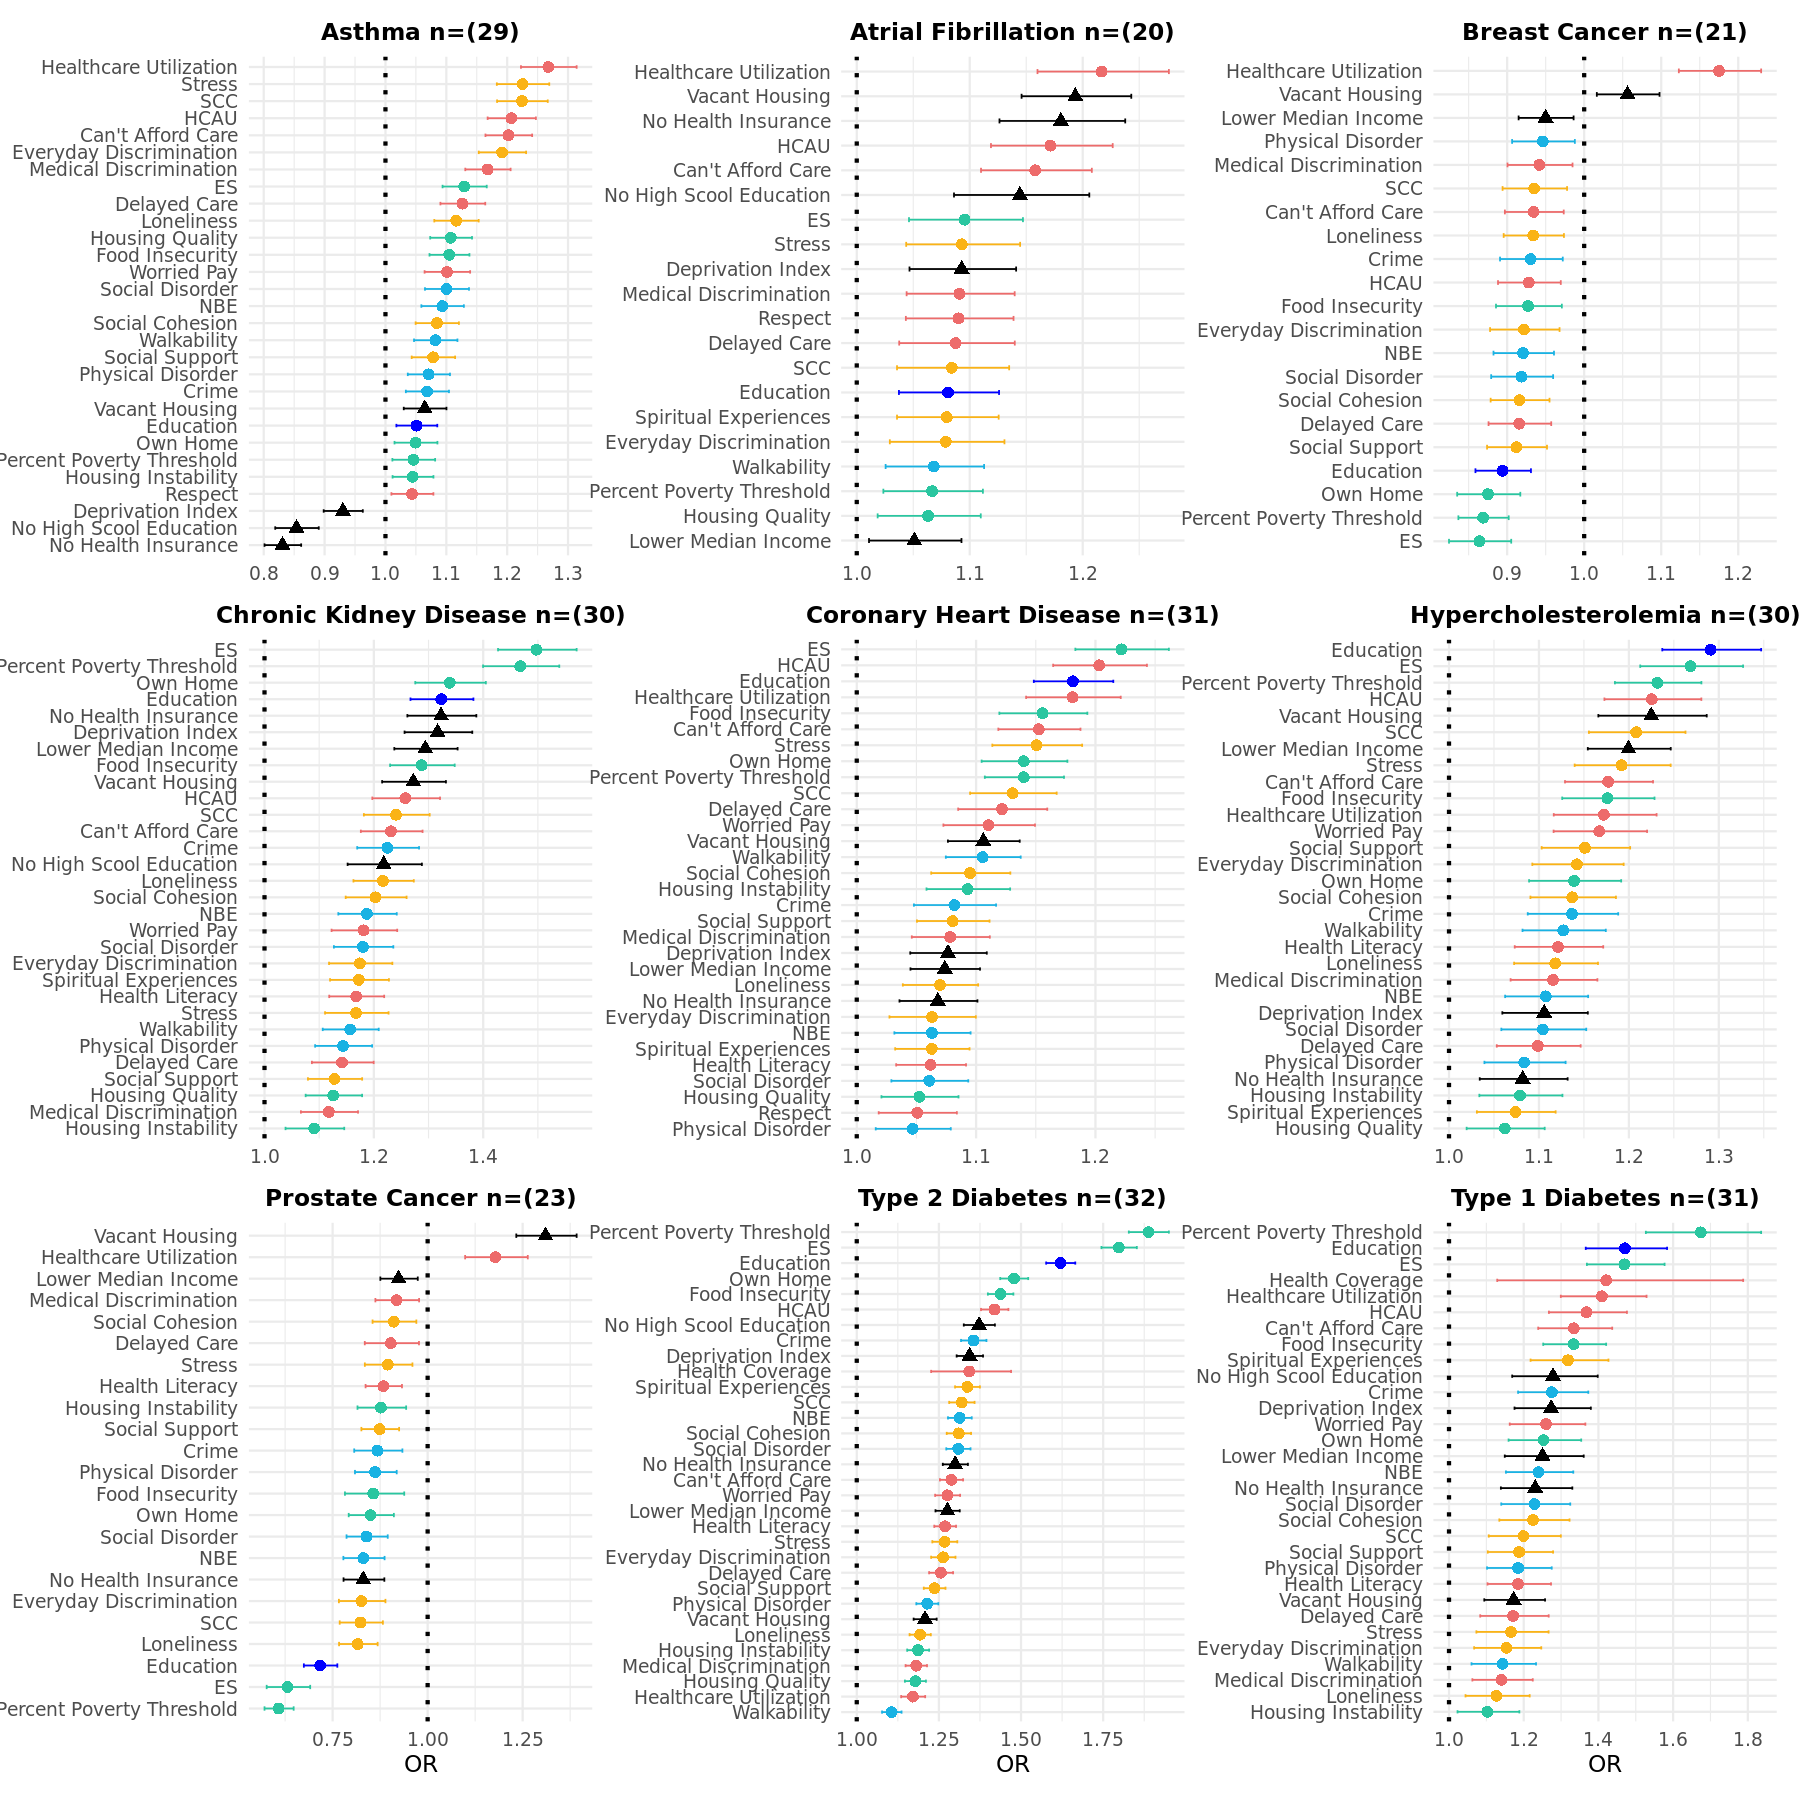

In [29]:

plot_for_disease_OR <- function(disease_name, data, show_x_label = FALSE) {
  disease_data <- data %>%
    filter(Disease == disease_name)
   
    domain_order <- disease_data %>%
      group_by(term) %>%
      arrange(OR) %>%
      pull(term) 
    
    
     disease_data <-  disease_data |> mutate(term= factor(term, levels = domain_order))
    
  x_axis_label <- if (show_x_label) "OR" else NULL

  plot_title <- paste0(disease_name_mapping[[disease_name]], " n=(", nrow(disease_data), ")")

  ggplot(disease_data, aes(x = OR, y = term, color = Domain, shape = shape)) +
    geom_point(size = 3) +
    geom_errorbarh(aes(xmin = OR_Lower, xmax = OR_Upper),
                   height = 0.2) +
    scale_color_manual(values = custom_colors, name = "Domain Type") +
    scale_y_discrete(labels = domain_labels) + 
    labs(
      title = plot_title,
      x = x_axis_label,
      y = NULL
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.y = element_text(),         # Always show y-axis labels
      axis.text.x = element_text(),
      legend.position = "none",
      plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
    ) +
    geom_vline(xintercept = 1, linetype = "dotted", color = "black", linewidth = 1.2)
}

plots <- lapply(seq_along(unique_diseases), function(i) {
  show_x_label <- i > (length(unique_diseases) - ncol_grid)
  plot_for_disease_OR(unique_diseases[i], results_filtered, show_x_label)
})


# Combine all plots into a grid
combined_plot <- wrap_plots(plots, ncol = ncol_grid)  # Adjust `ncol` as needed

# Display the combined plot with fixed size
options(repr.plot.width = 15, repr.plot.height = 15)
print(combined_plot)

# Save the combined plot
ggsave("combined_OR_plots_OR_bottom.png", plot = combined_plot, width = 15, height = 15, dpi = 300)


# Correlation Matrix

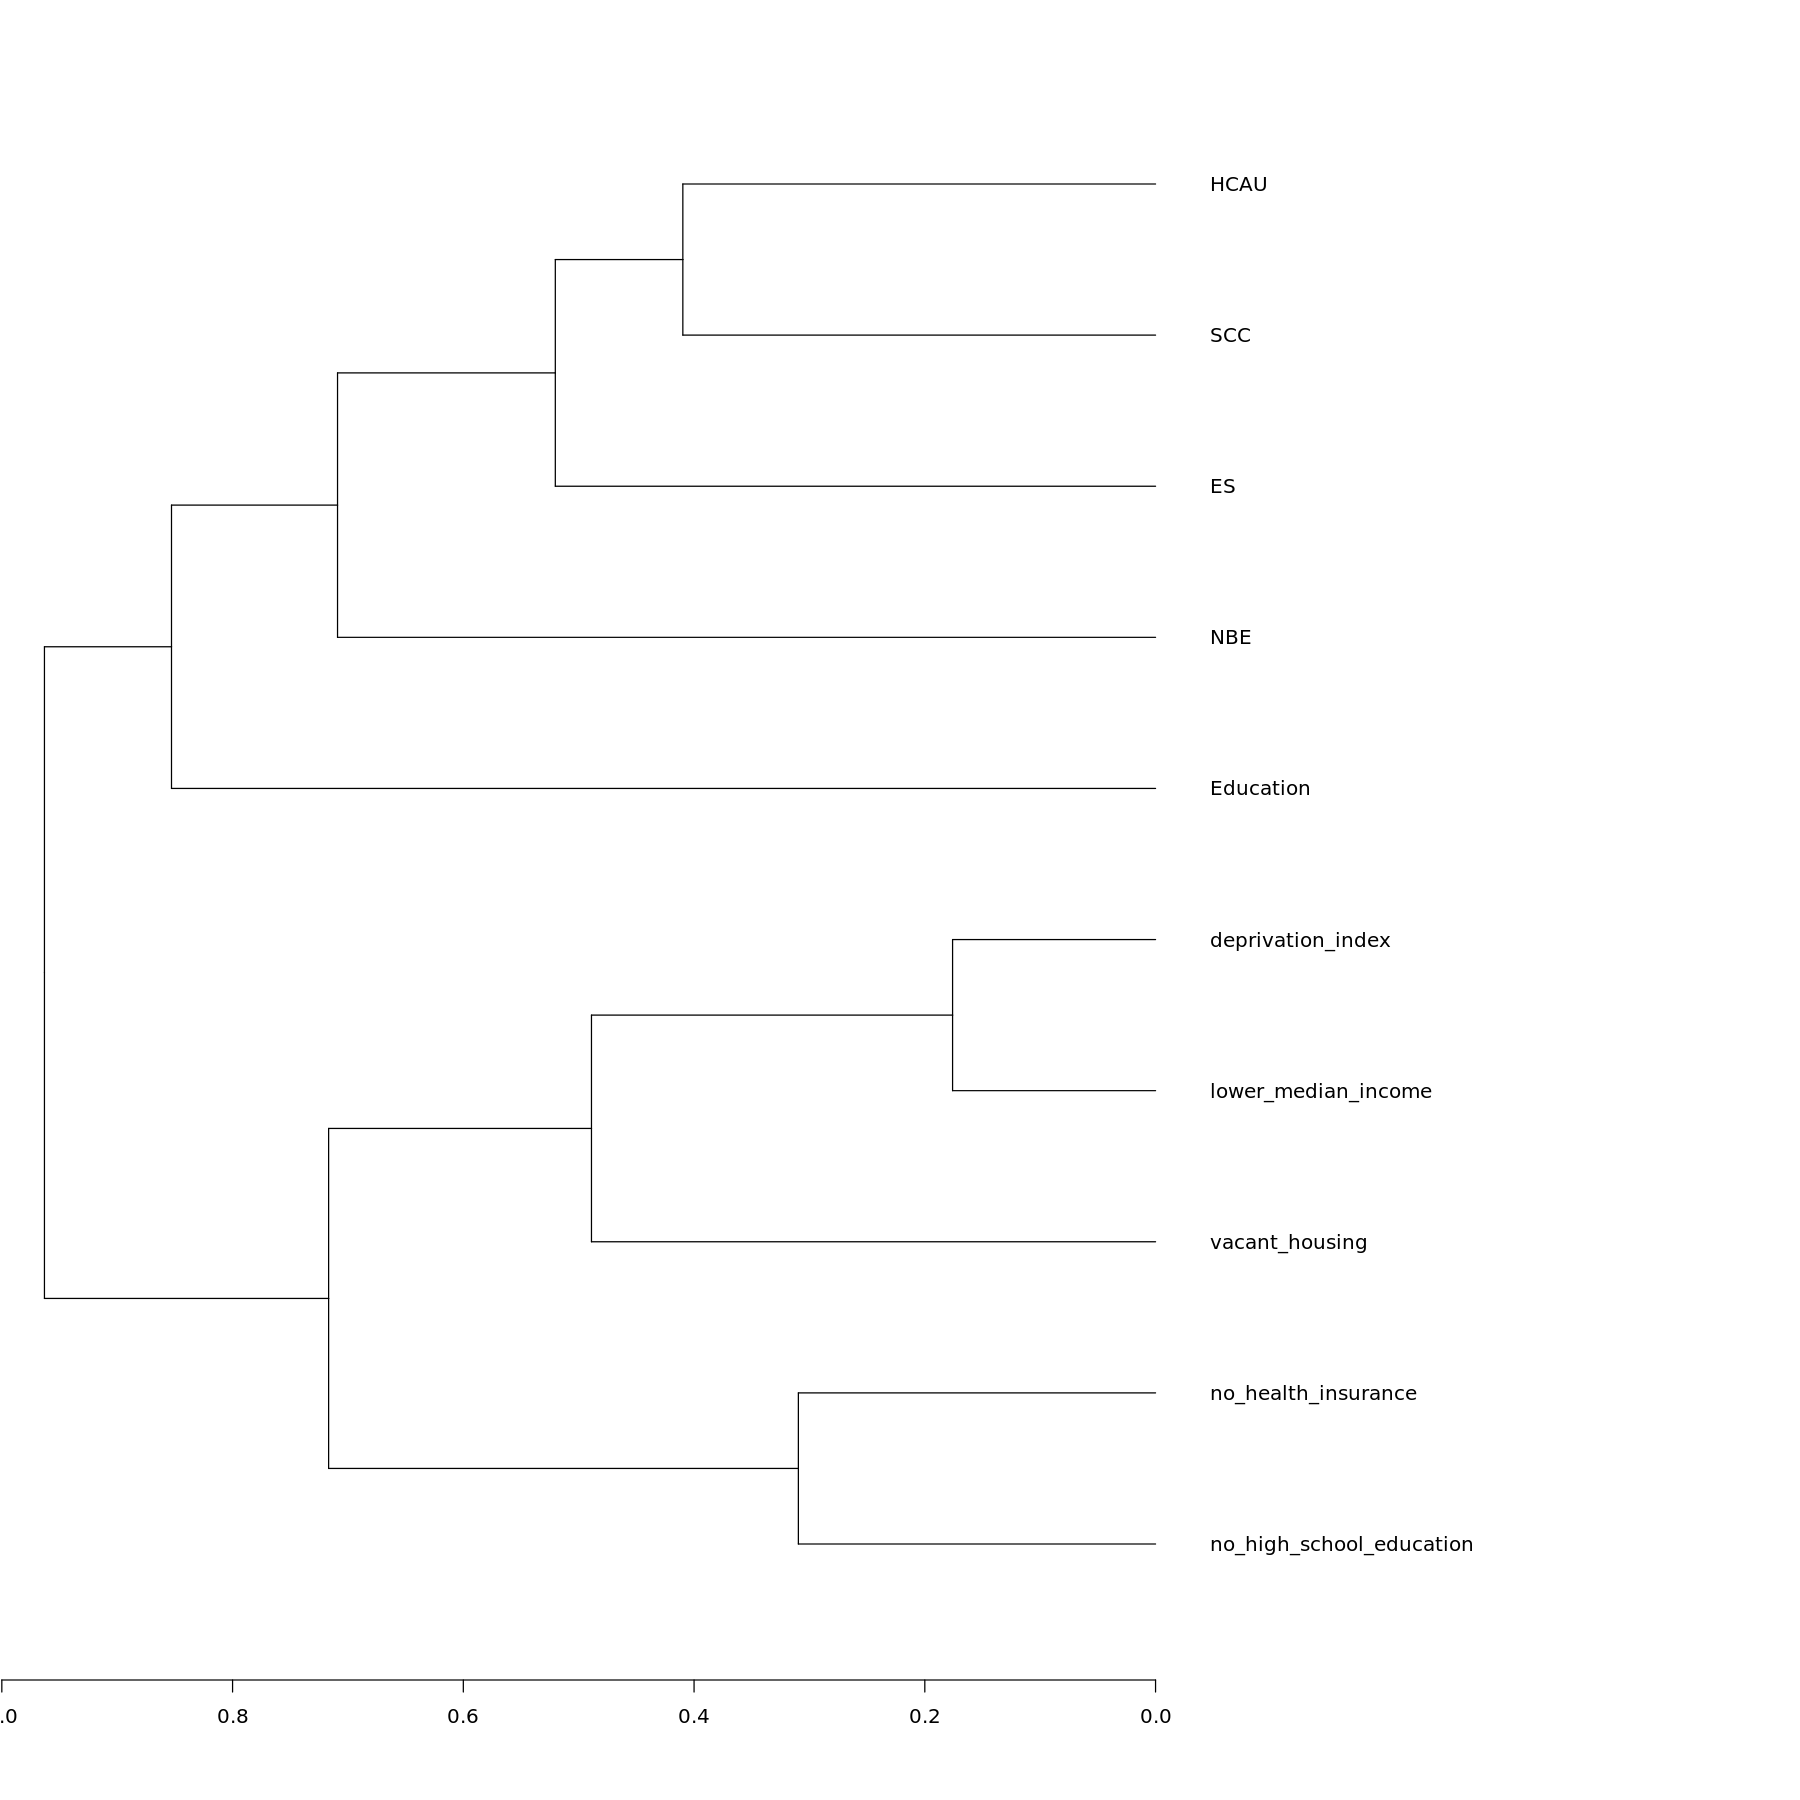

In [30]:
covariates<-c("age", "Cis_male", "Cis_female", "SGM", "visit_frequency", "record_depth")
All_SDoH_data_cor <- merged_data[, all_domains]


cor_matrix <- cor(All_SDoH_data_cor, use = "pairwise.complete.obs")

# Compute hierarchical clustering
hc <- hclust(as.dist(1 - abs(cor_matrix)), method = "complete")

# Convert to dendrogram object
dend <- as.dendrogram(hc)

# Plot the rotated dendrogram
par(mar = c(5, 0, 2, 25))  # Adjust the margin for the bottom, left, top, and right sides respectively
plot(dend, horiz = TRUE)

In [31]:
# Get dimensions and column names of the matrix
n <- nrow(cor_matrix)
col_names <- colnames(cor_matrix)

# Get upper triangle indices (excluding diagonal)
upper_tri_indices <- which(upper.tri(cor_matrix, diag = FALSE), arr.ind = TRUE)

# Extract upper triangle values and corresponding row/column names
cor_values <- round(cor_matrix[upper_tri_indices],2)
row_names <- rownames(cor_matrix)[upper_tri_indices[, 1]]
col_names <- col_names[upper_tri_indices[, 2]]

# Combine row and column names with their respective correlation values
cor_data <- data.frame(
  Pair = paste(row_names, col_names, sep = " & "),
  Correlation = cor_values
)

# Sort by correlation value in descending order
cor_data_sorted <- cor_data[order(-abs(cor_data$Correlation)), ]


In [32]:
library(gplots)
# Define custom color palette (orange to blue gradient)
my_palette <- colorRampPalette(c("white", "orange"))(100)

# Assuming your correlation matrix is stored in 'correlation_matrix'

options(repr.plot.width = 12, repr.plot.height = 8)  # Set width and height

cell_labels <- round(cor_matrix, 2)
# Mask correlation labels: only show values > 0.2 (absolute value)
cell_labels <- round(cor_matrix, 2)
cell_labels[abs(cell_labels) < 0.2] <- ""  # Remove labels below threshold




Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




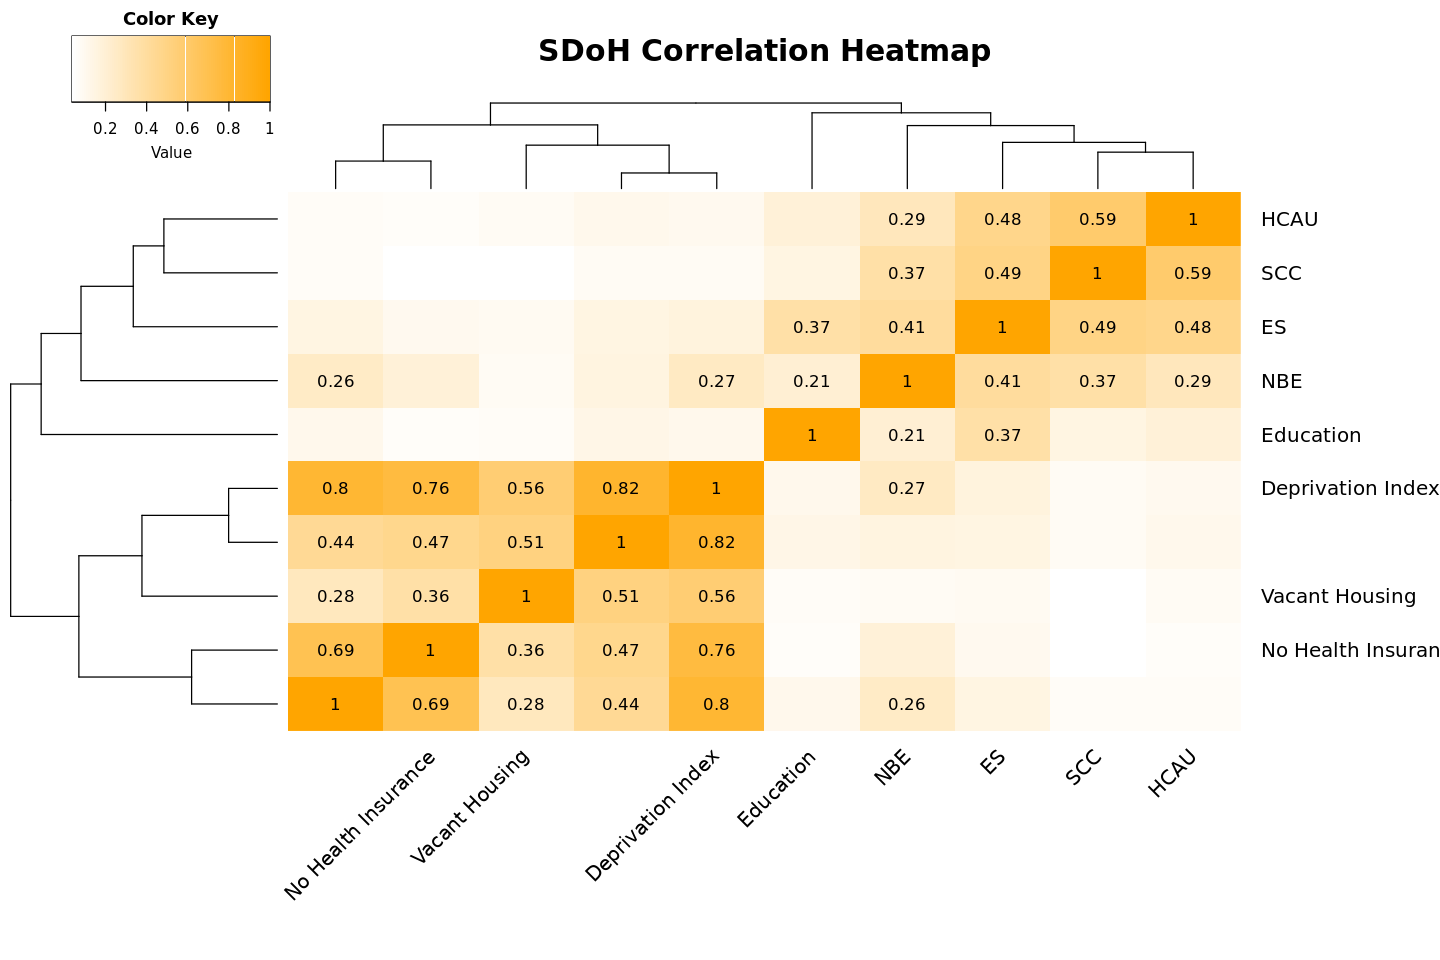

In [33]:
# Custom labels for rows and columns
label_mapping <- c(
  "vacant_housing" = "Vacant Housing",
  "poverty" = "Poverty",
  "median_income" = "Median Income",
  "no_health_insurance" = "No Health Insurance",
  "Education" = "Education",
  "high_school_education" = "High School Education",
  "assisted_income" = "Assisted Income",
  "deprivation_index" = "Deprivation Index",
  "SDOH" = "SDOH",
    "ES" = "ES",
    "NBE" = "NBE",
    "SCC" = "SCC",
    "Education" = "Education",
    "HCAU" = "HCAU"
)

# Apply custom labels to rows and columns
rownames(cor_matrix) <- label_mapping[rownames(cor_matrix)]
colnames(cor_matrix) <- label_mapping[colnames(cor_matrix)]

# Generate heatmap
heatmap.2(
  cor_matrix,
  Rowv = dend,  # Use the dendrogram for row clustering
  Colv = dend,  # Use the same dendrogram for column clustering
  dendrogram = "both",  # Show dendrogram for both rows and columns
  scale = "none",  # Do not scale data
  key = TRUE,  # Show color key
  keysize = 1.0,  # Size of color key
  notecol="black",
  trace = "none",  # Do not show trace lines
  density.info = "none",  # Do not show density plot
  cellnote = cell_labels,  # Add correlation values as labels
  margins = c(11.5, 10),  # Set margins
  main = "SDoH Correlation Heatmap",  # Main title
  col = my_palette,  # Use custom color
  srtCol = 45  # Rotate x-axis (column) labels
)


In [34]:
# Save as PNG
png(filename = "SDoH_Correlation_Heatmap.png", width = 1250, height = 1100, res = 140)
dev.control(displaylist = "enable")  # ✅ Ensure the plot is captured
heatmap.2(cor_matrix, 
          Rowv = dend,
          Colv = dend,
          dendrogram = "none",
          scale = "none",
          key = FALSE,
          trace = "none",
          density.info = "none",
          notecol="black",
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(11.5, 11.5),
          main = " ",
          col = my_palette,
          srtCol = 90,  # Rotate x-axis (column) labels
          labRow = rownames(cor_matrix)  # Explicitly set row labels
)
dev.off()  # ✅ Finalize the file


pdf 
  2

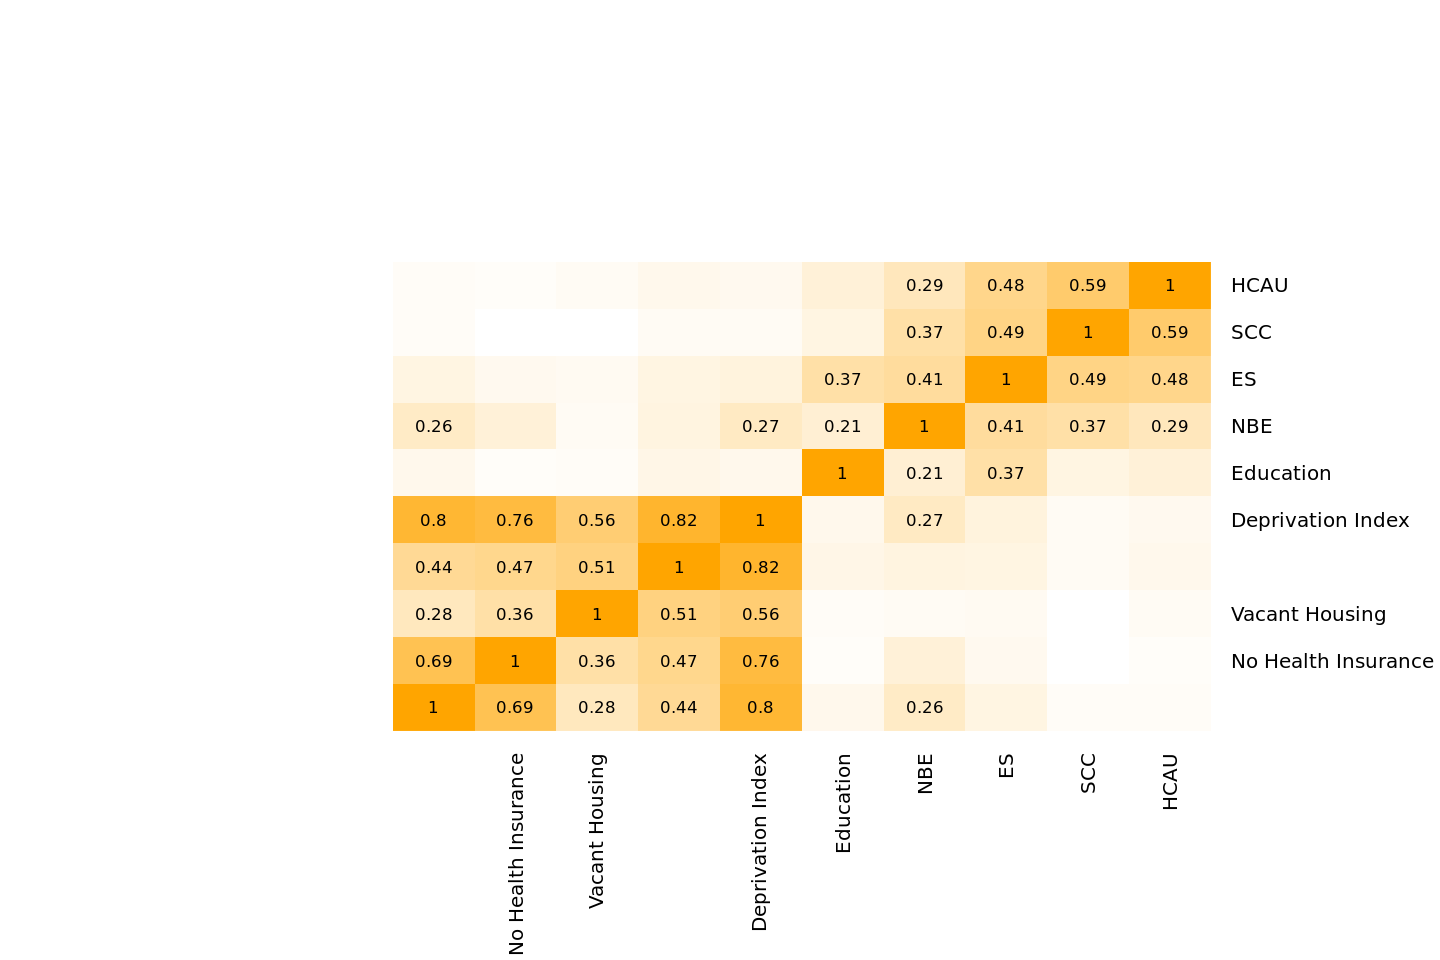

In [35]:
heatmap.2(cor_matrix, 
          Rowv = dend,
          Colv = dend,
          dendrogram = "none",
          scale = "none",
          key = FALSE,
          trace = "none",
          density.info = "none",
          notecol="black",
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(11.5, 11.5),
          main = " ",
          col = my_palette,
          srtCol = 90,  # Rotate x-axis (column) labels
          labRow = rownames(cor_matrix)  # Explicitly set row labels
)